# 01 EDA — 전국 개관 + 인천 집중

**공모전** AI금융빅데이터플랫폼 제1회 공모전 (~2026.9.22)
**데이터** `data/ABP_CONTEST_DATA.csv` — BC카드 2026년 1~6월, 시군구 × 업종 × 소비 주체 × 연령 월별 집계

### 공식 코드 정의 (주최측 데이터 명세)
| 컬럼 | 정의 |
|---|---|
| `STRD_YYMM` | 기준년월 (202601~202606) |
| `SIDO_NM` / `CCG_NM` | 광역시도 / 시군구 |
| `GENDER_CD` | **1=남성, 2=여성, 3=외국인, x=법인** |
| `AGE_CD` | **1=20대 이하, 2=20대, 3=30대, 4=40대, 5=50대, 6=60대 이상, x=법인** |
| `TP_BUZ_NO` / `TP_BUZ_NM` | 비씨카드 업종 코드 / 명칭 (외식 8종 + 식료품 유통 3종) |
| `amt` / `cnt` | 카드 이용금액 합계(원) / 건수 합계(건) |

> **주의**: `GENDER_CD`는 성별이 아니라 **소비 주체 구분**이다. 남성·여성·외국인·법인이 한 컬럼에 섞여 있으므로,
> 성별/연령 분석은 반드시 **내국인(1,2)만** 필터링해야 하고, 외국인·법인은 **독립된 세그먼트**로 다뤄야 한다.

### 목차
**0. 공통** — 0.1 환경 설정 · 0.2 데이터 로드·실사

**Part A. 전국 EDA — 데이터 전체의 구조**
A1 소비 주체 세그먼트 → A2 분포·집중도 → A3 축별 프로파일 → A4 교차 분석 → A5 외국인 소비의 두 얼굴 → A6 성장·쇠퇴 → A7 요약

**Part B. 인천 집중 EDA — 인천e음 캐시백 확대와 카드소비 대체**
B0 인천 분석 설정 → B1 인천 커버리지 → B2 정책 타임라인 → B3 인천 프로파일 → B4 시계열 → B5 사전 추세·반사실 갭 → B6 전국 속 인천의 위치 → B7 업종별(플라시보) → B8 군구별 → B9 소비 주체·연령 → B10 인접 지역 → B11 요약·본분석 설계

## 0.1 환경 설정

In [1]:
import warnings; warnings.filterwarnings("ignore")
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager as fm
from matplotlib.patches import Patch
import seaborn as sns

CSV = "../data/ABP_CONTEST_DATA.csv"
EOK, JO = 1e8, 1e12                                  # 억원, 조원
MONTHS = [202601, 202602, 202603, 202604, 202605, 202606]
MLAB   = ["1월", "2월", "3월", "4월", "5월", "6월"]
PRE, POST = MONTHS[:4], MONTHS[4:]                   # 캐시백 10% 기간 / 20% 기간
BIG5 = ["부산광역시", "대구광역시", "광주광역시", "대전광역시", "울산광역시"]

# 공식 코드북
SEG = {"1": "남성", "2": "여성", "3": "외국인", "x": "법인"}
AGE = {"1": "20대 이하", "2": "20대", "3": "30대", "4": "40대", "5": "50대", "6": "60대 이상", "x": "법인"}
AGE_ORDER = ["20대 이하", "20대", "30대", "40대", "50대", "60대 이상"]

pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)

## 0.2 데이터 로드·실사

In [2]:
df = pd.read_csv(CSV, dtype={"GENDER_CD": str, "AGE_CD": str, "TP_BUZ_NO": str})
KEYS = ["STRD_YYMM", "SIDO_NM", "CCG_NM", "GENDER_CD", "AGE_CD", "TP_BUZ_NO"]

print("shape     :", df.shape)
display(df.head())
print("결측치    :", int(df.isna().sum().sum()), " / 키 중복 :", int(df.duplicated(KEYS).sum()))
print("amt<=0    :", int((df.amt <= 0).sum()), " / cnt<=0 :", int((df.cnt <= 0).sum()))
print("기간      :", df.STRD_YYMM.min(), "~", df.STRD_YYMM.max(), f"({df.STRD_YYMM.nunique()}개월)")
print("커버리지  :", df.SIDO_NM.nunique(), "시도 /", df.groupby(["SIDO_NM", "CCG_NM"]).ngroups, "시군구 /", df.TP_BUZ_NO.nunique(), "업종")
print("셀 하한   : amt 최소", f"{df.amt.min():,}원 / cnt 최소", df.cnt.min(), "건  → 소액·소건수 셀은 미수록(합계는 소폭 과소)")
print("금액 단위 : 만원 단위 반올림 비율", (df.amt % 10_000 == 0).mean())
print(f"\n총 결제금액 {df.amt.sum()/JO:,.2f}조원 · 총 결제건수 {df.cnt.sum()/EOK:,.2f}억 건 · 객단가 {df.amt.sum()/df.cnt.sum():,.0f}원")

print("\n[ 코드북 실측 : 소비 주체 × 연령 행수 ]  — 외국인도 연령 코드 보유, 'x'는 법인 전용")
display(pd.crosstab(df.GENDER_CD.map(SEG), df.AGE_CD.map(AGE)).reindex(["남성", "여성", "외국인", "법인"]))
print("[ 업종 ]")
display(df.groupby(["TP_BUZ_NO", "TP_BUZ_NM"]).agg(행수=("amt", "size"), 금액_억=("amt", lambda s: s.sum() / EOK))
          .sort_values("금액_억", ascending=False).round(0))

shape     : (242574, 9)


,STRD_YYMM,SIDO_NM,CCG_NM,GENDER_CD,AGE_CD,TP_BUZ_NO,TP_BUZ_NM,amt,cnt
0,202605,서울특별시,용산구,2,3,8006,서양음식,734430000,38874
1,202605,부산광역시,사상구,2,4,8001,일반한식,424220000,10929
2,202601,경상북도,포항시 북구,1,5,4010,편 의 점,283030000,29848
3,202601,전라남도,여수시,1,6,4010,편 의 점,204060000,20727
4,202606,서울특별시,송파구,1,3,4010,편 의 점,575120000,86780


결측치    : 0  / 키 중복 : 0
amt<=0    : 0  / cnt<=0 : 0
기간      : 202601 ~ 202606 (6개월)
커버리지  : 17 시도 / 255 시군구 / 11 업종
셀 하한   : amt 최소 20,000원 / cnt 최소 11 건  → 소액·소건수 셀은 미수록(합계는 소폭 과소)
금액 단위 : 만원 단위 반올림 비율 1.0

총 결제금액 17.22조원 · 총 결제건수 9.49억 건 · 객단가 18,149원

[ 코드북 실측 : 소비 주체 × 연령 행수 ]  — 외국인도 연령 코드 보유, 'x'는 법인 전용


AGE_CD,20대,20대 이하,30대,40대,50대,60대 이상,법인
GENDER_CD,,,,,,,
남성,13241,12181,13480,13679,13929,14044,0
여성,13040,11546,13291,13442,13633,13729,0
외국인,12152,7566,12564,12641,12702,12553,0
법인,0,0,0,0,0,0,13161


[ 업종 ]


,,행수,금액_억
TP_BUZ_NO,TP_BUZ_NM,,
8001,일반한식,28406,63485.0
4020,슈퍼 마켓,28456,27239.0
4010,편 의 점,28967,24839.0
8006,서양음식,28627,19161.0
4004,대형할인점,21529,16548.0
8021,스넥,27438,5715.0
8005,중국음식,26805,5296.0
8301,제 과 점,27224,4984.0
8004,일식회집,21714,4878.0


In [3]:
# 파생 변수
df["ym"]      = pd.to_datetime(df.STRD_YYMM.astype(str), format="%Y%m")
df["unit"]    = df.amt / df.cnt                                  # 객단가
df["seg"]     = df.GENDER_CD.map(SEG)                            # 소비 주체
df["age"]     = df.AGE_CD.map(AGE)
df["region"]  = df.SIDO_NM + " " + df.CCG_NM
df["biz"]     = df.TP_BUZ_NM.str.replace(" ", "")               # '편 의 점' → '편의점'
df["is_ind"]  = df.GENDER_CD.isin(["1", "2"])                    # 내국인 개인
df["is_ic"]   = df.SIDO_NM.eq("인천광역시")
df["n_month"] = df.groupby(KEYS[1:]).STRD_YYMM.transform("nunique")   # 셀이 수록된 월 수 (균형패널 검정용)

# Part A — 내국인 전용 프레임 (성별·연령 분석용)
dom = df[df.is_ind].copy()
dom["gender"] = dom.GENDER_CD.map(SEG)

# Part B — 내국인 개인 기준, 인천 / 전국(인천 제외)
ind      = df[df.is_ind]
icn, nat = ind[ind.is_ic], ind[~ind.is_ic]
ic_all   = df[df.is_ic]
print(f"전체 {len(df):,}행 · 내국인 개인 {len(ind):,}행 · 인천 {len(ic_all):,}행 (인천 내국인 개인 {len(icn):,}행)")

전체 242,574행 · 내국인 개인 159,235행 · 인천 9,623행 (인천 내국인 개인 6,317행)


### 인사이트 · 데이터 구조

- **집계 데이터**: `월 × 시도 × 시군구 × 소비주체 × 연령 × 업종` 단위. 결측·중복·음수 **전무** → 전처리 부담 없음. 다만 **셀 하한(amt ≥ 2만원, cnt ≥ 11건)** 이 있어 소액 셀은 빠져 있다 → 합계는 소폭 과소.
- **6개월 / 17개 시도 / 233개 시군구 / 11개 업종**, 총 **17.2조원 · 9.5억 건 · 객단가 18,150원**.
- **업종이 전부 먹거리**: 외식 8종 + 식료품 유통 3종. 이 데이터는 사실상 **"식(食) 소비 데이터셋"** 이며, 주제도 여기서 벗어날 수 없다.
- **명세와 실제의 차이 1건**: 명세는 `AGE_CD='x'`를 "법인/외국인"으로 적었으나, 실제로는 **외국인에게도 연령 코드 1~6이 부여**되어 있고 `'x'`는 법인 전용이다. → **외국인은 연령별 분석이 가능**하다.

---
# Part A. 전국 EDA — 데이터 전체의 구조

전국 시군구·업종·소비 주체를 가로질러 데이터의 성격을 파악한다. 여기서 확인한 사실(소비 주체 분리 필요성, 법인 계절성, 성장률 착시)이 Part B의 분석 기준이 된다.

In [4]:
# Part A 차트 스타일 (seaborn whitegrid)
sns.set_theme(style="whitegrid", font="AppleGothic", rc={"axes.unicode_minus": False})
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## A1. 소비 주체 세그먼트 — 이 데이터의 숨은 축

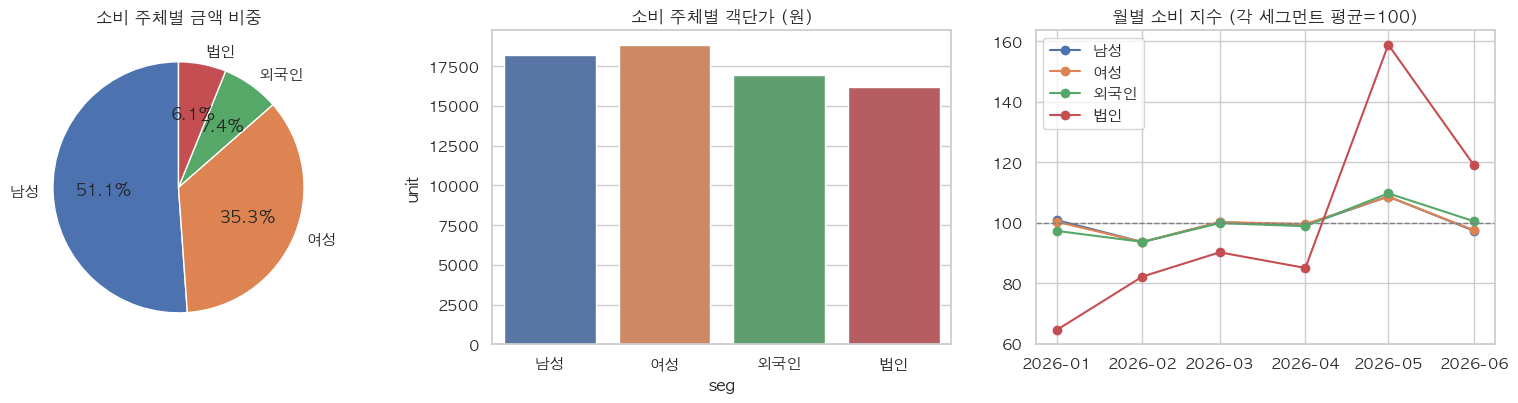

,share,unit
seg,,
남성,51.10,"18,166.40"
여성,35.30,"18,800.70"
외국인,7.40,"16,926.20"
법인,6.10,"16,195.40"


In [5]:
seg = df.groupby("seg").agg(amt=("amt", "sum"), cnt=("cnt", "sum"))
seg["share"] = seg["amt"] / seg["amt"].sum() * 100
seg["unit"]  = seg["amt"] / seg["cnt"]
seg = seg.reindex(["남성", "여성", "외국인", "법인"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].pie(seg["share"], labels=seg.index, autopct="%1.1f%%", startangle=90,
            colors=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
axes[0].set_title("소비 주체별 금액 비중")

sns.barplot(x=seg.index, y=seg["unit"], ax=axes[1],
            palette=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
axes[1].set_title("소비 주체별 객단가 (원)")

# 월별 계절성 (평균=100 지수)
for s, c in zip(seg.index, ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]):
    m = df[df["seg"] == s].groupby("ym")["amt"].sum()
    axes[2].plot(m.index, m / m.mean() * 100, marker="o", label=s, color=c)
axes[2].axhline(100, ls="--", c="gray", lw=1)
axes[2].set_title("월별 소비 지수 (각 세그먼트 평균=100)")
axes[2].legend()
plt.tight_layout(); plt.show()

display(seg[["share", "unit"]].round(1))

### 인사이트 · 소비 주체

- **외국인 7.4% (1.28조원), 법인 6.1% (1.06조원)** — 합쳐서 전체의 **13.5%**. 이걸 "성별 불명"으로 뭉개면 데이터의 8분의 1을 버리는 셈이다.
- **법인 소비의 계절성이 극단적이다**: 1월 지수 65 → **5월 159** → 6월 119. 내국인·외국인이 94~110 범위에서 거의 평평한 것과 대조적이다.
  → **5월 전체 소비 피크의 실질적 동인은 법인카드**(회식·행사·접대)다. "가정의 달 외식 증가"라는 통념과 다른 해석.
- 외국인 소비는 오히려 **계절 변동이 거의 없다**(CV 5.3%). 관광객이 주도한다면 나타났어야 할 성수기 변동이 없다 → **정주(定住) 외국인의 생활 소비**가 지배적이라는 강한 단서. (A5에서 검증)


## A2. 분포와 집중도

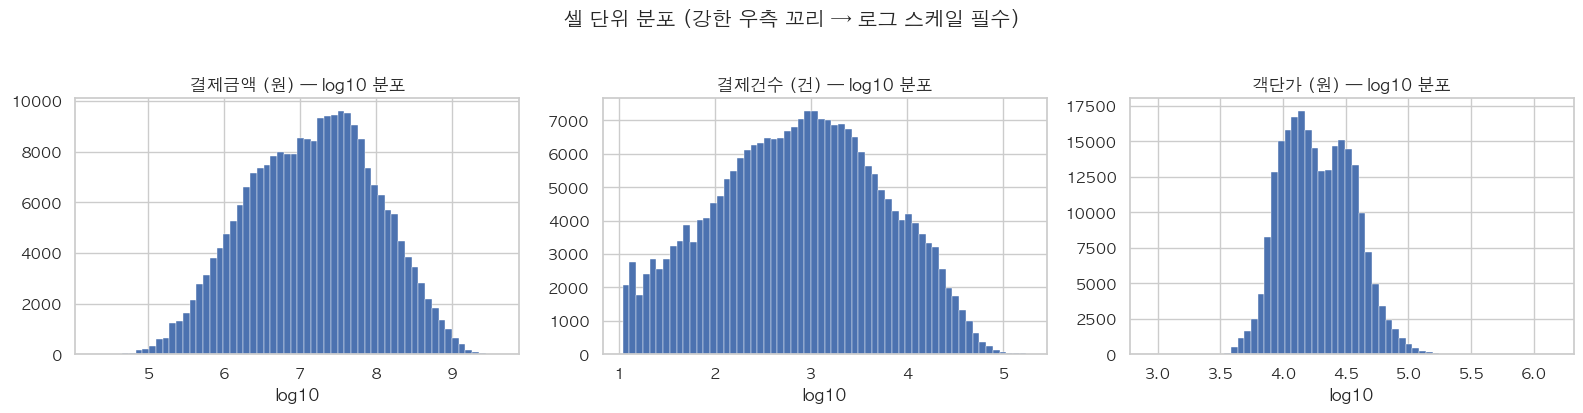

,count,mean,std,min,25%,50%,75%,max
amt,"242,574.00","71,008,847.07","165,374,742.64","20,000.00","3,440,000.00","16,000,000.00","60,450,000.00","4,247,220,000.00"
cnt,"242,574.00","3,912.64","8,560.84",11.00,178.00,810.00,"3,330.00","174,529.00"
unit,"242,574.00","23,781.19","18,480.53",869.57,"11,513.49","18,223.41","31,261.61","1,445,555.56"


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(axes, ["amt", "cnt", "unit"],
                          ["결제금액 (원)", "결제건수 (건)", "객단가 (원)"]):
    ax.hist(np.log10(df[col]), bins=60, color="#4C72B0", edgecolor="white", linewidth=.3)
    ax.set_title(f"{title} — log10 분포"); ax.set_xlabel("log10")
plt.suptitle("셀 단위 분포 (강한 우측 꼬리 → 로그 스케일 필수)", y=1.03)
plt.tight_layout(); plt.show()

display(df[["amt", "cnt", "unit"]].describe().T)

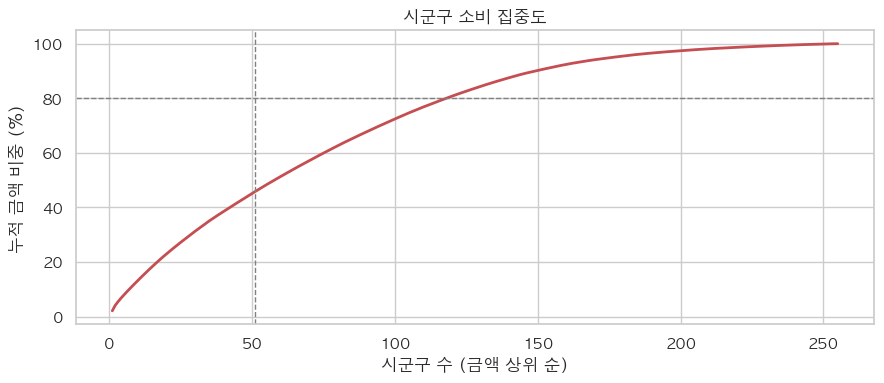

상위 10개 시군구 : 13.3%
상위 20% 시군구  : 45.8%



,금액_조원
region,
제주특별자치도 제주시,0.36
서울특별시 강남구,0.34
대구광역시 달서구,0.23
부산광역시 부산진구,0.22
경기도 시흥시,0.20
서울특별시 송파구,0.19
경기도 평택시,0.19
서울특별시 서초구,0.18
광주광역시 광산구,0.18


In [7]:
reg = df.groupby("region")["amt"].sum().sort_values(ascending=False)
cum = reg.cumsum() / reg.sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(reg)+1), cum.values * 100, color="#C44E52", lw=2)
ax.axhline(80, ls="--", c="gray", lw=1); ax.axvline(len(reg)*0.2, ls="--", c="gray", lw=1)
ax.set_xlabel("시군구 수 (금액 상위 순)"); ax.set_ylabel("누적 금액 비중 (%)")
ax.set_title("시군구 소비 집중도")
plt.tight_layout(); plt.show()

print(f"상위 10개 시군구 : {reg.head(10).sum()/reg.sum()*100:,.1f}%")
print(f"상위 20% 시군구  : {reg.head(int(len(reg)*.2)).sum()/reg.sum()*100:,.1f}%\n")
display((reg.head(10) / JO).round(2).to_frame("금액_조원"))

### 인사이트 · 분포

- 금액·건수 모두 **로그정규에 가까운 우측 꼬리**. 이후 분석은 로그 스케일 또는 **정규화 지표(객단가·비중·LQ)** 로 다뤄야 한다.
- 집중도는 **완만**하다(상위 10개 13.3%, 상위 20%가 45.8%). 소수 상권 쏠림이 아닌 **전국에 퍼진 생활 소비**.
- **시군구 금액 1위가 제주시** — 강남구보다 위다. 인구 규모로 설명되지 않으며, A1에서 본 외국인 축과 연결된다.


## A3. 축별 프로파일

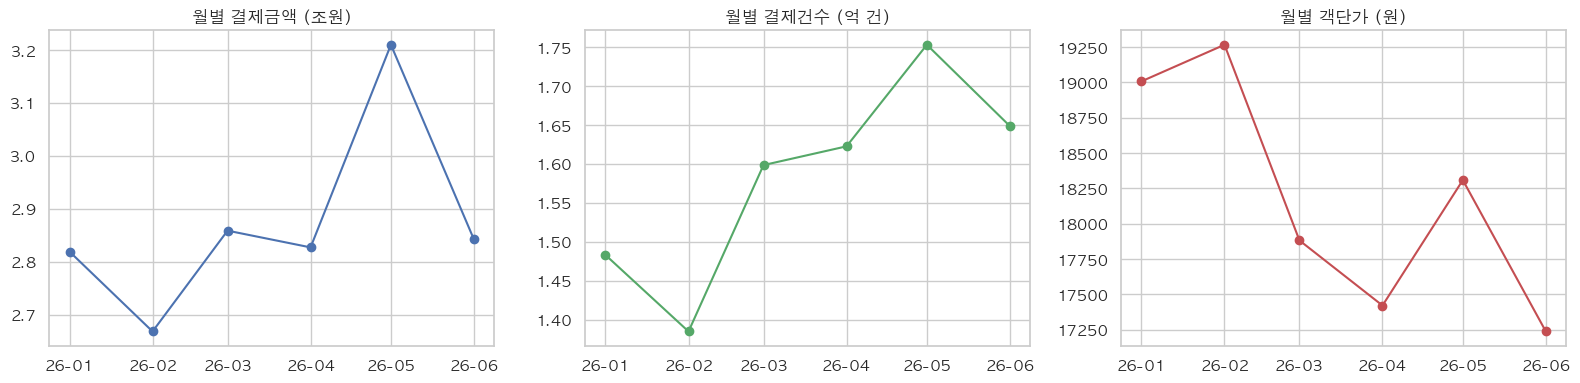

,금액_조,건수_억,unit
ym,,,
2026-01-01,2.82,1.48,"19,008.00"
2026-02-01,2.67,1.38,"19,266.89"
2026-03-01,2.86,1.60,"17,882.38"
2026-04-01,2.83,1.62,"17,421.98"
2026-05-01,3.21,1.75,"18,309.39"
2026-06-01,2.84,1.65,"17,238.34"


In [8]:
m = df.groupby("ym").agg(amt=("amt", "sum"), cnt=("cnt", "sum"))
m["unit"] = m["amt"] / m["cnt"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(m.index, m["amt"]/JO, marker="o", color="#4C72B0"); axes[0].set_title("월별 결제금액 (조원)")
axes[1].plot(m.index, m["cnt"]/EOK, marker="o", color="#55A868"); axes[1].set_title("월별 결제건수 (억 건)")
axes[2].plot(m.index, m["unit"], marker="o", color="#C44E52"); axes[2].set_title("월별 객단가 (원)")
for ax in axes:
    ax.set_xticks(m.index); ax.set_xticklabels([d.strftime("%y-%m") for d in m.index])
plt.tight_layout(); plt.show()

display(m.assign(금액_조=m["amt"]/JO, 건수_억=m["cnt"]/EOK)[["금액_조", "건수_억", "unit"]].round(2))

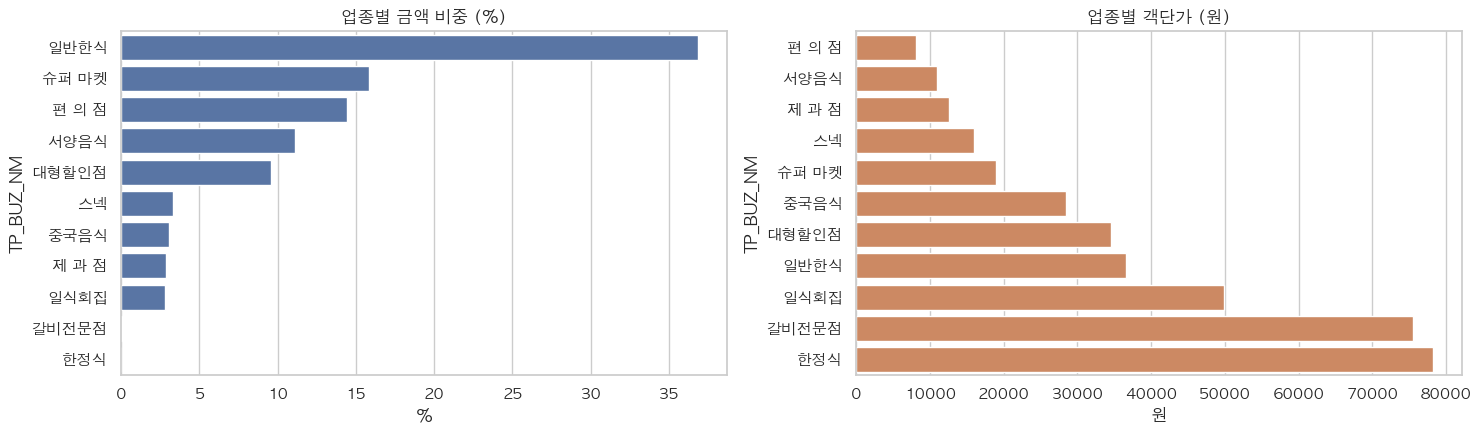

,share,unit
TP_BUZ_NM,,
일반한식,36.90,"36,632.50"
슈퍼 마켓,15.80,"19,010.60"
편 의 점,14.40,"8,117.20"
서양음식,11.10,"10,965.30"
대형할인점,9.60,"34,542.20"
스넥,3.30,"15,998.40"
중국음식,3.10,"28,523.20"
제 과 점,2.90,"12,563.70"
일식회집,2.80,"49,926.00"


In [9]:
biz = df.groupby("TP_BUZ_NM").agg(amt=("amt", "sum"), cnt=("cnt", "sum"))
biz["unit"]  = biz["amt"] / biz["cnt"]
biz["share"] = biz["amt"] / biz["amt"].sum() * 100
biz = biz.sort_values("amt", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(x=biz["share"], y=biz.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("업종별 금액 비중 (%)"); axes[0].set_xlabel("%")
u = biz["unit"].sort_values()
sns.barplot(x=u, y=u.index, ax=axes[1], color="#DD8452")
axes[1].set_title("업종별 객단가 (원)"); axes[1].set_xlabel("원")
plt.tight_layout(); plt.show()

display(biz[["share", "unit"]].round(1))

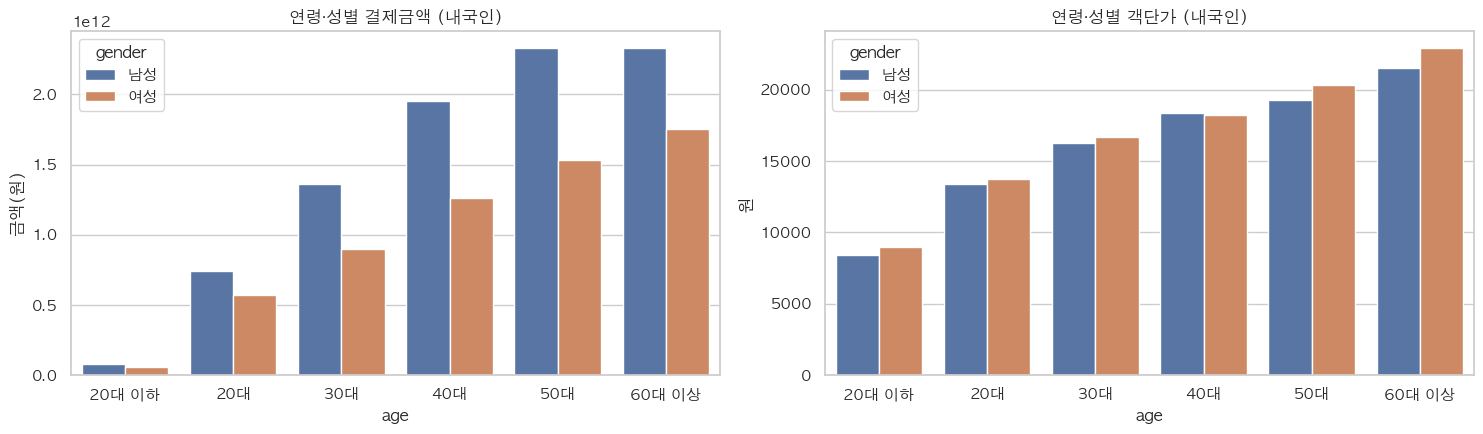

,share,unit
age,,
20대 이하,1.00,"8,635.80"
20대,8.90,"13,543.50"
30대,15.20,"16,419.70"
40대,21.60,"18,320.30"
50대,26.00,"19,693.80"
60대 이상,27.40,"22,091.10"


In [10]:
# 연령 x 성별 — 내국인만
ag = dom.groupby(["age", "gender"]).agg(amt=("amt", "sum"), cnt=("cnt", "sum")).reset_index()
ag["unit"] = ag["amt"] / ag["cnt"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(data=ag, x="age", y="amt", hue="gender", order=AGE_ORDER, ax=axes[0])
axes[0].set_title("연령·성별 결제금액 (내국인)"); axes[0].set_ylabel("금액(원)")
sns.barplot(data=ag, x="age", y="unit", hue="gender", order=AGE_ORDER, ax=axes[1])
axes[1].set_title("연령·성별 객단가 (내국인)"); axes[1].set_ylabel("원")
plt.tight_layout(); plt.show()

t = dom.groupby("age").agg(amt=("amt", "sum"), cnt=("cnt", "sum")).reindex(AGE_ORDER)
t["share"] = t["amt"] / t["amt"].sum() * 100
t["unit"]  = t["amt"] / t["cnt"]
display(t[["share", "unit"]].round(1))

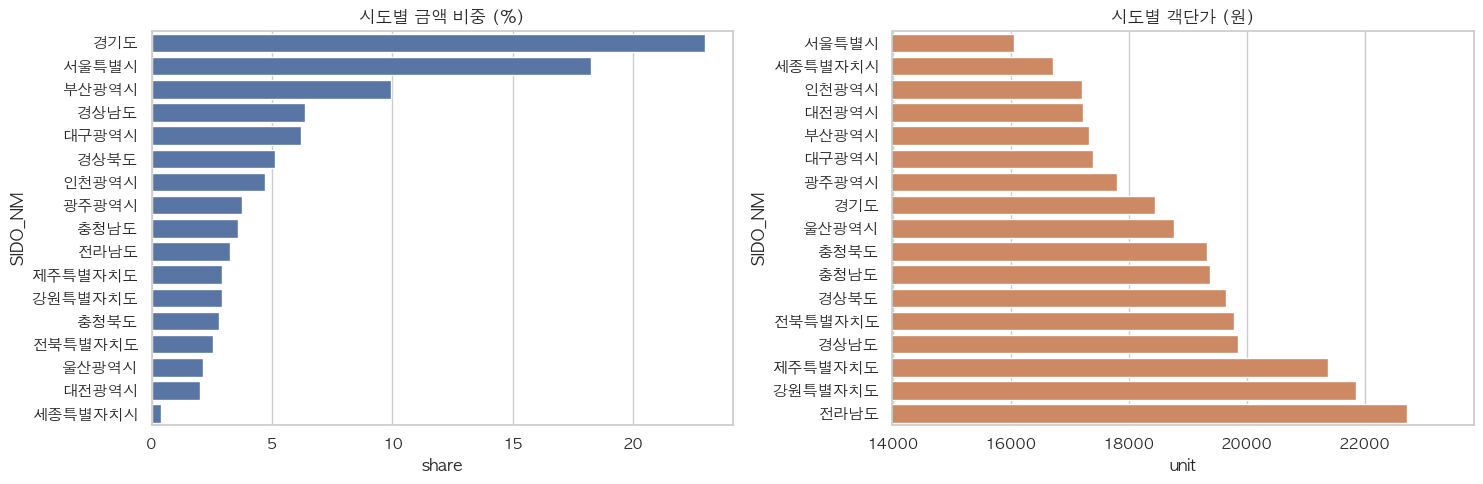

,share,unit
SIDO_NM,,
경기도,23.00,"18,453.90"
서울특별시,18.30,"16,051.30"
부산광역시,9.90,"17,333.80"
경상남도,6.40,"19,846.50"
대구광역시,6.20,"17,393.20"
경상북도,5.10,"19,657.20"
인천광역시,4.70,"17,213.40"
광주광역시,3.80,"17,798.40"
충청남도,3.60,"19,384.60"


In [11]:
sido = df.groupby("SIDO_NM").agg(amt=("amt", "sum"), cnt=("cnt", "sum"))
sido["unit"]  = sido["amt"] / sido["cnt"]
sido["share"] = sido["amt"] / sido["amt"].sum() * 100
sido = sido.sort_values("amt", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=sido["share"], y=sido.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("시도별 금액 비중 (%)")
s2 = sido["unit"].sort_values()
sns.barplot(x=s2, y=s2.index, ax=axes[1], color="#DD8452")
axes[1].set_title("시도별 객단가 (원)"); axes[1].set_xlim(14000, None)
plt.tight_layout(); plt.show()

display(sido[["share", "unit"]].round(1))

### 인사이트 · 축별 프로파일

- **시간**: 5월이 뚜렷한 피크(3.21조, +12% vs 2월)이나 **동인은 법인카드**(A1). 객단가는 1~2월이 최고(19.0~19.3천원), 6월 최저(17.2천원) → 연초 "적게·비싸게" → 이후 "자주·싸게"로 전환.
- **업종**: `일반한식`이 **금액 36.9%로 압도적 1위**이면서 객단가도 36.6천원(편의점 8.1천원의 4.5배). 개인 끼니가 아닌 **모임·회식 성격**의 소비 지표.
- **연령(내국인)**: 20대 이하 1.0% → 60대 이상 27.4%로 단조 증가, **객단가도 8.6천원 → 22.1천원으로 2.6배**. 원인은 업종 구성 차이(A4에서 확인).
- **성별(내국인)**: 남성 59.1% / 여성 40.9%로 금액 격차가 크지만 **객단가는 여성이 오히려 높다**(18.8천원 vs 18.2천원). 결제 명의 편중일 가능성이 커서 성별 해석은 신중해야 한다.
- **지역**: 금액은 경기(23.0%)·서울(18.3%) 집중이나 **객단가 상위는 전남(22.7천원)·강원(21.8천원)·제주(21.4천원)**. 서울은 최하위권(16.1천원). → **"규모의 지역"과 "단가의 지역"이 완전히 다르다.**


## A4. 교차 분석

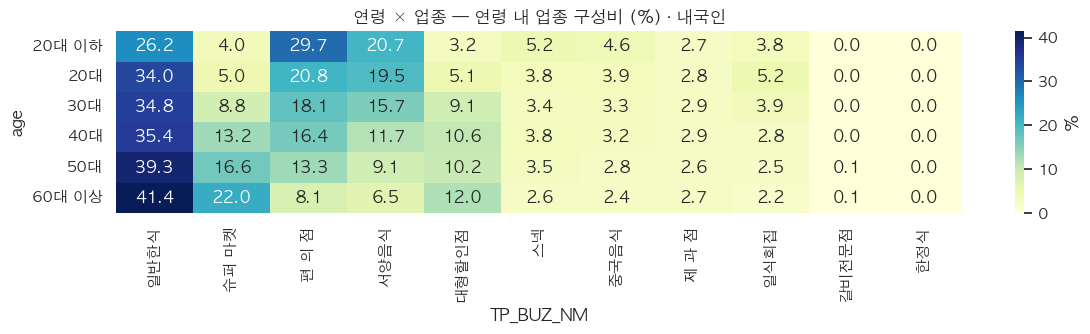

In [12]:
BIZ_ORDER = df.groupby("TP_BUZ_NM")["amt"].sum().sort_values(ascending=False).index

def heat(data, index_col, title):
    piv = data.pivot_table(index=index_col, columns="TP_BUZ_NM", values="amt", aggfunc="sum").fillna(0)
    piv = (piv.div(piv.sum(axis=1), axis=0) * 100)[BIZ_ORDER]
    fig, ax = plt.subplots(figsize=(12, max(3.5, len(piv)*0.42)))
    sns.heatmap(piv, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "%"}, ax=ax)
    ax.set_title(title); plt.tight_layout(); plt.show()
    return piv

_ = heat(dom.assign(age=pd.Categorical(dom["age"], AGE_ORDER, ordered=True)),
         "age", "연령 × 업종 — 연령 내 업종 구성비 (%) · 내국인")

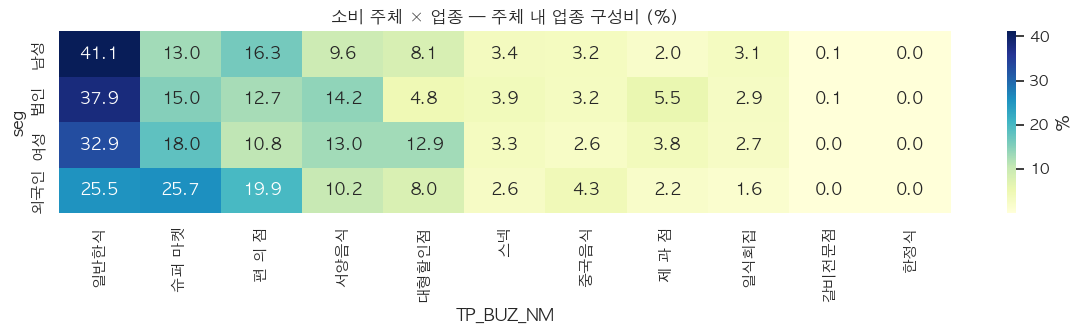

In [13]:
_ = heat(df, "seg", "소비 주체 × 업종 — 주체 내 업종 구성비 (%)")

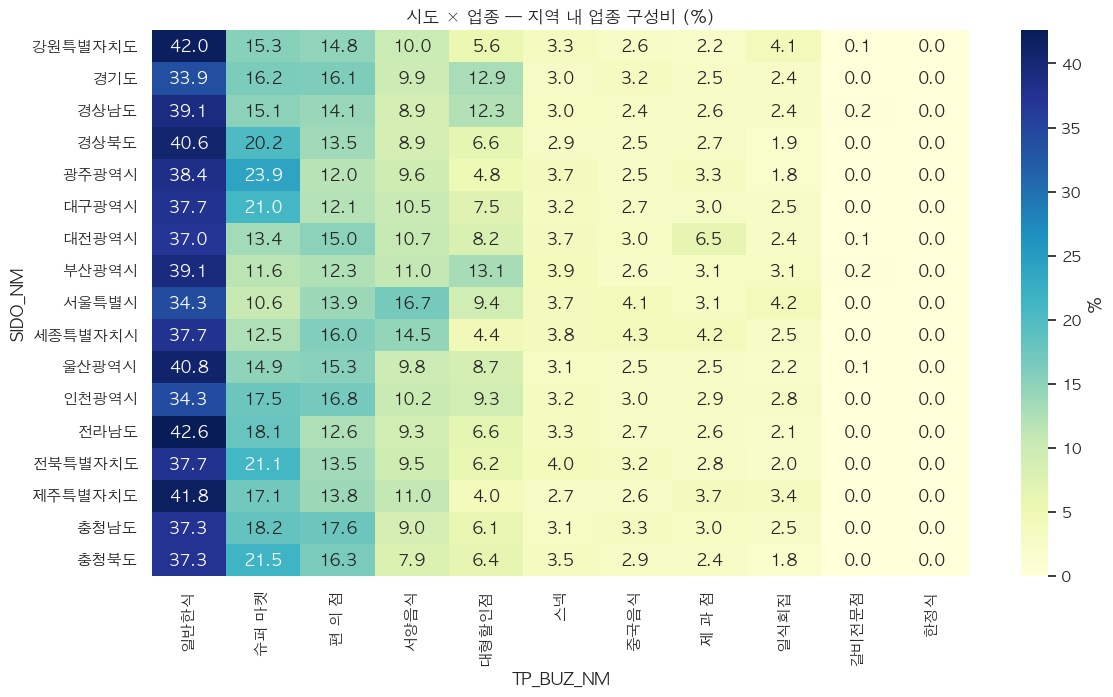

In [14]:
_ = heat(df, "SIDO_NM", "시도 × 업종 — 지역 내 업종 구성비 (%)")

In [15]:
# 입지계수(LQ) : 전국 대비 해당 지역에서 특정 업종이 얼마나 과대표되는가
piv = df.pivot_table(index="region", columns="TP_BUZ_NM", values="amt", aggfunc="sum").fillna(0)
reg_share = piv.div(piv.sum(axis=1), axis=0)
nat_share = piv.sum(axis=0) / piv.sum().sum()
lq = reg_share / nat_share

big  = piv.sum(axis=1)
keep = big >= big.quantile(0.25)      # 소규모 지역 노이즈 제외
lq_f = lq[keep]

for b in ["일반한식", "일식회집", "대형할인점", "편 의 점"]:
    print(f"── LQ 상위 지역 : {b} ──")
    print(lq_f[b].sort_values(ascending=False).head(7).round(2).to_string(), "\n")

── LQ 상위 지역 : 일반한식 ──
region
전라남도 담양군    1.65
전라남도 화순군    1.40
충청남도 공주시    1.40
경상북도 문경시    1.40
충청남도 예산군    1.35
인천광역시 강화군   1.35
부산광역시 중구    1.34 

── LQ 상위 지역 : 일식회집 ──
region
충청남도 홍성군      3.64
강원특별자치도 속초시   2.79
서울특별시 마포구     2.77
경기도 성남시 분당구   2.46
강원특별자치도 강릉시   2.45
대구광역시 중구      2.22
부산광역시 중구      2.06 

── LQ 상위 지역 : 대형할인점 ──
region
경기도 여주시       5.40
부산광역시 북구      5.00
경기도 하남시       3.54
인천광역시 동구      3.51
경기도 수원시 장안구   3.22
경기도 부천시 소사구   2.94
전라남도 광양시      2.68 

── LQ 상위 지역 : 편 의 점 ──
region
충청북도 음성군      1.66
경기도 화성시 만세구   1.59
경기도 평택시       1.56
충청북도 진천군      1.51
부산광역시 동구      1.51
인천광역시 미추홀구    1.48
충청남도 아산시      1.44 



In [16]:
# 시군구 유형화 : 업종 구성비 벡터 KMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X  = reg_share.loc[lq_f.index]
km = KMeans(n_clusters=4, n_init=20, random_state=42).fit(StandardScaler().fit_transform(X))

prof = X.copy(); prof["cluster"] = km.labels_; prof["amt"] = big.loc[X.index]
summary = prof.groupby("cluster").agg(지역수=("amt", "size"),
                                      평균금액_억=("amt", lambda s: s.mean()/EOK))
summary = summary.join((prof.groupby("cluster")[list(BIZ_ORDER[:6])].mean() * 100).round(1))
display(summary.round(1))

for c in sorted(prof["cluster"].unique()):
    names = prof[prof["cluster"] == c].sort_values("amt", ascending=False).index[:8]
    print(f"[클러스터 {c}] " + ", ".join(names))

,지역수,평균금액_억,일반한식,슈퍼 마켓,편 의 점,서양음식,대형할인점,스넥
cluster,,,,,,,,
0,125,798.00,38.20,19.40,15.20,9.20,7.10,3.20
1,21,844.30,31.90,13.60,12.40,8.00,24.40,2.80
2,1,671.80,34.90,12.60,12.00,8.40,3.30,3.90
3,44,"1,099.40",37.90,10.00,14.00,14.90,8.10,3.80


[클러스터 0] 제주특별자치도 제주시, 대구광역시 달서구, 경기도 시흥시, 경기도 평택시, 광주광역시 광산구, 경상남도 김해시, 대구광역시 북구, 광주광역시 북구
[클러스터 1] 부산광역시 북구, 경기도 고양시 덕양구, 경상북도 포항시 북구, 서울특별시 노원구, 부산광역시 기장군, 경기도 하남시, 서울특별시 은평구, 부산광역시 사상구
[클러스터 2] 대전광역시 중구
[클러스터 3] 서울특별시 강남구, 부산광역시 부산진구, 서울특별시 송파구, 서울특별시 서초구, 서울특별시 영등포구, 대구광역시 수성구, 서울특별시 마포구, 부산광역시 해운대구


### 인사이트 · 교차 분석

- **연령 × 업종이 가장 선명하다**: 젊을수록 편의점·스넥·제과, 고연령일수록 일반한식·대형할인점. 객단가 2.6배 격차의 실체는 **업종 구성 차이**다.
- **주체 × 업종**: 외국인은 **슈퍼마켓 25.7%**(내국인 15.0%)로 압도적으로 높고 한식은 25.5%(내국인 37.8%)로 낮다. 반면 **법인은 제과점 5.5%·서양음식 14.2%** 가 두드러진다(내국인 2.8%·11.0%) → 법인카드의 **접대·행사용 소비** 성격.
- **LQ가 절대 금액으로는 안 보이는 지역 성격을 드러낸다**: `일식회집`은 속초(2.79)·강릉(2.45)·부산 중구(2.06) 등 **해안 관광 상권**, `일반한식`은 담양(1.65)·화순·공주 등 **군 단위 지역**(외식 선택지가 좁다는 뜻이기도 하다), `대형할인점`은 여주(5.40)·하남(3.54) 등 **교외형 대형점 입지**.
- **클러스터링 결과 시군구는 3개 유형 + 이상치 1개**로 갈린다 — 슈퍼마켓 편중의 **생활·주거형(125개)**, 대형할인점 24.4%의 **대형점 거점형(21개)**, 서양음식 14.9%·평균금액 최대의 **도심 상권형(44개, 강남·송파·서초·해운대)**. 이 라벨은 후속 분석의 **설명 변수로 재사용** 가능하다.


## A5. 외국인 소비의 두 얼굴 — 관광형 vs 정주형

In [17]:
# 지역별 외국인·법인 소비 비중
p = df.pivot_table(index="region", columns="seg", values="amt", aggfunc="sum").fillna(0)
p["tot"] = p.sum(axis=1)
p = p[p["tot"] >= p["tot"].quantile(0.25)]
p["외국인비중"] = p["외국인"] / p["tot"] * 100
p["법인비중"]   = p["법인"]   / p["tot"] * 100

# 해당 지역 '외국인 소비'의 업종 구성
fp   = df[df["seg"] == "외국인"].pivot_table(index="region", columns="TP_BUZ_NM",
                                            values="amt", aggfunc="sum").fillna(0)
fcomp = (fp.div(fp.sum(axis=1), axis=0) * 100).loc[p.index]

top = p.nlargest(15, "외국인비중").join(fcomp[["슈퍼 마켓", "일반한식", "편 의 점"]])
top = top.rename(columns={"슈퍼 마켓": "외국인_슈퍼%", "일반한식": "외국인_한식%",
                          "편 의 점": "외국인_편의점%"})
display(top[["외국인비중", "외국인_슈퍼%", "외국인_한식%", "외국인_편의점%"]].round(1))

,외국인비중,외국인_슈퍼%,외국인_한식%,외국인_편의점%
region,,,,
제주특별자치도 제주시,33.00,20.60,39.20,14.40
전라남도 영암군,31.80,54.40,11.30,16.70
제주특별자치도 서귀포시,26.60,20.60,37.30,15.30
충청북도 음성군,26.50,42.80,11.40,30.30
경기도 화성시 만세구,25.20,44.10,14.60,24.70
충청북도 진천군,23.30,44.50,14.30,25.70
경기도 안산시 단원구,21.00,27.00,14.90,18.80
경기도 시흥시,18.10,31.20,19.30,19.20
충청남도 아산시,16.20,40.60,14.70,24.10


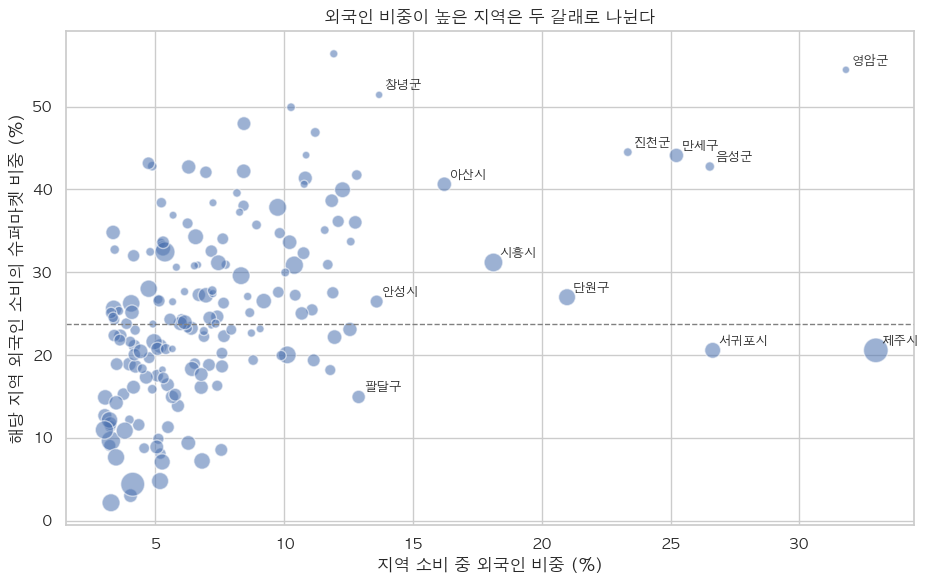

In [18]:
# 외국인 소비 비중 vs 그 소비의 슈퍼마켓 편중도 → 두 집단이 갈린다
sc = p.join(fcomp[["슈퍼 마켓", "일반한식"]]).dropna()
sc = sc[sc["외국인비중"] >= 3]

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(sc["외국인비중"], sc["슈퍼 마켓"], s=sc["tot"]/sc["tot"].max()*300 + 15,
           alpha=.55, color="#4C72B0", edgecolor="white")
ax.axhline(fcomp["슈퍼 마켓"].median(), ls="--", c="gray", lw=1)
ax.set_xlabel("지역 소비 중 외국인 비중 (%)")
ax.set_ylabel("해당 지역 외국인 소비의 슈퍼마켓 비중 (%)")
ax.set_title("외국인 비중이 높은 지역은 두 갈래로 나뉜다")

for r in sc.nlargest(12, "외국인비중").index:
    ax.annotate(r.split()[-1], (sc.loc[r, "외국인비중"], sc.loc[r, "슈퍼 마켓"]),
                fontsize=9, xytext=(4, 4), textcoords="offset points")
plt.tight_layout(); plt.show()

In [19]:
# 법인 비중 상위 지역
display(p.nlargest(12, "법인비중")[["법인비중", "외국인비중"]].round(1))

seg,법인비중,외국인비중
region,,
경상북도 포항시 북구,34.20,2.40
경상북도 포항시 남구,30.00,3.40
광주광역시 남구,23.30,4.20
광주광역시 북구,20.80,4.70
광주광역시 동구,20.30,4.80
대구광역시 남구,18.30,3.40
대구광역시 동구,17.10,2.70
대구광역시 수성구,16.60,3.00
광주광역시 서구,15.30,4.90


### 인사이트 · 외국인/법인 지역 구조 (가장 차별화된 발견)

**외국인 비중 상위 지역은 성격이 정반대인 두 집단이 섞여 있다.** 구분 기준은 **외국인 소비의 업종 구성**이다.

| 유형 | 지역 | 외국인 비중 | 외국인 소비의 업종 구성 |
|---|---|---|---|
| **관광형** | 제주시 33.0%, 서귀포시 26.6% | 최상위 | **한식 37~39%**, 슈퍼 20.6% → 외식 중심 |
| **정주 노동형** | 영암군 31.8%, 음성군 26.5%, 화성 만세구 25.2%, 진천군 23.3%, 안산 단원구 21.0%, 창녕군 13.7% | 최상위 | **슈퍼마켓 42~54%**, 한식 11~15% → 장보기 중심 |

- 영암(대불산단)·음성·진천·화성·아산·창녕·안산 단원구는 모두 **산업단지 배후 외국인 노동자 밀집지**다. 이들의 소비는 관광이 아니라 **생활 장보기**이며, 그래서 슈퍼마켓 비중이 절반에 육박한다.
- A1에서 본 **외국인 소비의 계절 무변동(CV 5.3%)** 이 이 해석을 뒷받침한다. 관광이 주도했다면 성수기 변동이 나타났어야 한다.
- **법인 비중은 완전히 다른 지도를 그린다**: 포항 북구 34.2%·남구 30.0%, 광주 남구 23.3%·북구 20.8%, 대구 남구 18.3%. **산업도시·업무지구**에 몰려 있고, 관광지(제주시 9.4%)와는 겹치지 않는다.
- → **외국인 비중·법인 비중·업종 구성 3개 지표만으로 시군구를 관광 상권 / 산단 배후 상권 / 업무 상권 / 주거 상권으로 분류**할 수 있다. 이것이 이 데이터에서만 나오는 고유 자산이다.


## A6. 성장 · 쇠퇴 상권

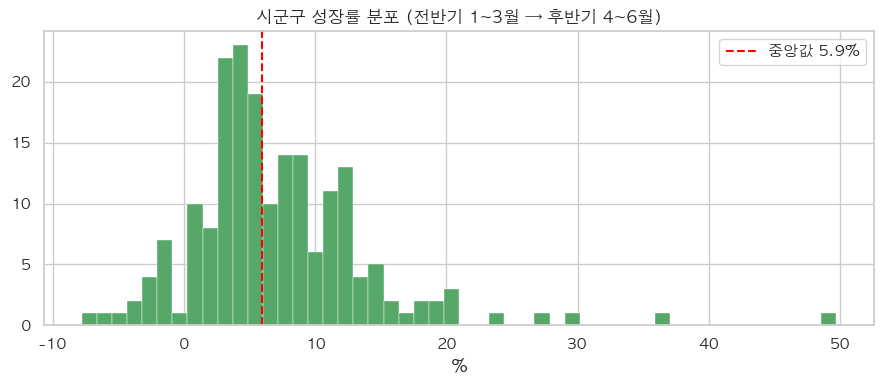

── 성장 상위 10 ──
region
충청남도 태안군         49.70
경기도 가평군          36.60
부산광역시 서구         29.70
부산광역시 영도구        26.80
경기도 과천시          24.30
경상남도 창원시 진해구     20.60
경상남도 창원시 마산회원구   20.10
부산광역시 사하구        20.10
충청남도 공주시         19.60
경기도 양평군          19.50

── 성장 하위 10 ──
region
강원특별자치도 평창군   -7.80
경상남도 양산시      -5.50
인천광역시 계양구     -4.40
충청남도 홍성군      -3.90
인천광역시 동구      -3.60
인천광역시 남동구     -2.80
인천광역시 부평구     -2.30
경기도 부천시 소사구   -2.20
인천광역시 연수구     -2.20
인천광역시 서구      -1.90


In [20]:
h1 = df[df["STRD_YYMM"] <= 202603].groupby("region")["amt"].sum()
h2 = df[df["STRD_YYMM"] >= 202604].groupby("region")["amt"].sum()

g = pd.DataFrame({"전반기": h1, "후반기": h2}).dropna()
g = g[g["전반기"] >= g["전반기"].quantile(0.25)]
g["성장률"] = (g["후반기"] / g["전반기"] - 1) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(g["성장률"], bins=50, color="#55A868", edgecolor="white", linewidth=.3)
ax.axvline(g["성장률"].median(), ls="--", c="red", label=f"중앙값 {g['성장률'].median():.1f}%")
ax.set_title("시군구 성장률 분포 (전반기 1~3월 → 후반기 4~6월)")
ax.set_xlabel("%"); ax.legend()
plt.tight_layout(); plt.show()

print("── 성장 상위 10 ──");  print(g.nlargest(10, "성장률")["성장률"].round(1).to_string())
print("\n── 성장 하위 10 ──"); print(g.nsmallest(10, "성장률")["성장률"].round(1).to_string())

In [21]:
# 성장률을 세그먼트별로 분해 — 무엇이 성장을 끌었나
seg_g = []
for s in ["남성", "여성", "외국인", "법인"]:
    d = df[df["seg"] == s]
    a = d[d["STRD_YYMM"] <= 202603].groupby("region")["amt"].sum()
    b = d[d["STRD_YYMM"] >= 202604].groupby("region")["amt"].sum()
    seg_g.append(((b / a - 1) * 100).rename(s))
seg_g = pd.concat(seg_g, axis=1).loc[g.index]

display(pd.concat([g[["성장률"]], seg_g], axis=1)
          .nlargest(8, "성장률").round(1))
display(pd.concat([g[["성장률"]], seg_g], axis=1)
          .nsmallest(8, "성장률").round(1))

,성장률,남성,여성,외국인,법인
region,,,,,
충청남도 태안군,49.70,54.00,58.50,42.00,9.80
경기도 가평군,36.60,36.20,38.50,25.10,54.50
부산광역시 서구,29.70,12.10,13.40,13.90,493.20
부산광역시 영도구,26.80,6.30,6.10,13.60,709.20
경기도 과천시,24.30,21.20,25.50,55.50,34.00
경상남도 창원시 진해구,20.60,-0.80,-2.10,-0.40,"1,128.70"
경상남도 창원시 마산회원구,20.10,-0.00,0.30,2.00,956.70
부산광역시 사하구,20.10,5.80,7.90,6.00,415.20


,성장률,남성,여성,외국인,법인
region,,,,,
강원특별자치도 평창군,-7.80,-9.40,-5.60,7.50,-27.70
경상남도 양산시,-5.50,-5.40,-6.80,-0.60,-0.90
인천광역시 계양구,-4.40,-4.20,-5.20,-5.00,9.10
충청남도 홍성군,-3.90,-6.20,-3.80,6.10,15.60
인천광역시 동구,-3.60,-3.20,-4.20,-5.70,6.60
인천광역시 남동구,-2.80,-3.40,-3.20,1.70,5.30
인천광역시 부평구,-2.30,-2.50,-2.40,-3.50,6.80
경기도 부천시 소사구,-2.20,-2.90,-1.60,-3.30,7.90


### 인사이트 · 성장·쇠퇴

- 대부분 시군구는 **+5~10%의 완만한 성장** (봄·5월 성수기 포함).
- **성장률 단일 숫자는 위험하다.** 세그먼트로 분해하면 성장 상위 지역이 두 부류로 갈린다.
  - **진짜 내국인 소비 성장**: 태안(+49.7%, 남성 +54.0%·여성 +58.5%), 가평(+36.6%), 과천(+24.3%) — 실체가 있는 성장.
  - **법인 폭증에 의한 착시**: 창원 진해구(전체 +20.6%인데 **법인 +1,128.7%**, 내국인은 −0.8%), 마산회원구(법인 +956.7%, 내국인 0.0%), 부산 영도구(법인 +709.2%, 내국인 +6.3%), 부산 서구(법인 +493.2%). → **상권이 살아난 게 아니라 특정 법인 결제가 유입된 것**일 가능성이 높다. 상권 진단에 그대로 쓰면 오판한다.
- **성장 하위엔 인천이 계양·동구·남동·부평·서구·연수까지 동시 등장**하고, 분해해 보면 **내국인·외국인이 함께 마이너스**다(법인만 소폭 플러스). 개별 상권이 아니라 **도시 단위의 실질 소비 둔화** 신호로 볼 근거가 된다.
- 6개월 데이터라 **계절 효과와 구조적 성장을 완전히 분리할 수는 없다** — 한계로 명시해야 한다.

## A7. 요약 · 공모전 주제 연계

### 데이터 요약
| 항목 | 내용 |
|---|---|
| 범위 | 2026-01 ~ 2026-06 (6개월), 17개 시도 / 233개 시군구 / 11개 업종 |
| 규모 | 17.2조원 · 9.5억 건 · 평균 객단가 18,150원 |
| 성격 | 전부 외식 + 식료품 유통 → **식(食) 소비 데이터** |
| 구성 | 남성 51.1% / 여성 35.3% / **외국인 7.4% / 법인 6.1%** |
| 품질 | 결측·중복·이상치 없음. 명세 대비 차이 1건(외국인도 연령 코드 보유) |
| 제약 | 개인 식별 불가(집계), **인구·시간대·요일·점포수 정보 없음**, 6개월이라 연간 계절성 분리 불가 |

### 핵심 발견 5가지
1. **`GENDER_CD`는 성별 컬럼이 아니다** — 외국인·법인이 전체의 13.5%를 차지하는 **독립 세그먼트**. 이를 분리하는 것 자체가 분석의 출발점이자 차별점.
2. **외국인 소비는 관광형과 정주 노동형으로 갈린다** — 제주(한식 39%) vs 영암·음성·진천·화성(슈퍼마켓 42~54%). 계절 무변동이 정주형 우세를 뒷받침.
3. **5월 소비 피크의 동인은 법인카드** — 법인 지수 1월 65 → 5월 159. 내국인은 거의 평평하다.
4. **규모의 지역 ≠ 단가의 지역** — 금액은 수도권, 객단가는 전남·강원·제주. 시군구 1위는 제주시.
5. **성장률은 세그먼트 분해 없이는 오판을 부른다** — 창원 진해구·부산 영도구의 성장은 법인 결제 폭증(+700~1,100%)에 의한 착시이고, 내국인 소비는 제자리다.

### 공모전 주제별 연결
| 공식 주제 | 활용 방향 |
|---|---|
| **성장·쇠퇴 상권 분석** | A6의 성장률을 **세그먼트별로 분해**해 "누가 끌고 누가 빠졌나"로 진단. 법인 착시를 걷어낸 **내국인 기준 실질 성장률**이 이 대회에서 바로 쓸 수 있는 지표. 인천 6개 구 동반 둔화가 대표 사례. |
| **특정 업종·상권 마케팅** | A5의 **산단 배후 외국인 상권**은 지금까지 거의 다뤄지지 않은 시장. 슈퍼마켓 편중이라는 명확한 수요 신호가 있다. |
| **서비스 기획·분석 모델** | 외국인 비중 · 법인 비중 · 업종 구성 3지표로 **상권 유형 분류 모델**을 만들고, 유형별 성장 패턴 차이를 검증. |

### 후속에 필요한 외부 데이터
- 시군구별 **주민등록인구 + 등록외국인 수** → 1인당 소비 정규화, 정주형/관광형 판별의 결정적 근거
- **관광객 통계** → 관광형 상권 검증
- **사업체·점포 수 통계** → 공급 측면(점포당 매출) 분석


---
# Part B. 인천 집중 EDA — 인천e음 캐시백 확대와 카드소비 대체효과

**질문** 2026년 5~7월 인천e음 캐시백 확대(10% → 20%, 월 한도 30 → 50만원)가 인천의 **BC카드 소비를 얼마나 대체**했는가?

**전제 — 해석의 방향을 정한다**
- 인천e음 운영사(코나아이)는 2023년 8월 BC카드 결제망에서 KB국민카드 결제망으로 이전했다 → **이 데이터에 인천e음 결제는 들어 있지 않다.**
- 따라서 대체효과는 인천의 BC카드 소비가 전국 추세 대비 **덜 늘거나 줄어드는 것**으로 관측된다. 5~6월에 인천만 빠지면 그것이 신호다.

## B0. 인천 분석 설정 — 팔레트·공통 함수

In [22]:
# Part A의 seaborn 테마를 초기화하고 Part B 스타일 적용
mpl.rcdefaults()

# ── 한글 폰트
_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if _f in _avail:
        mpl.rc("font", family=_f); break
mpl.rc("axes", unicode_minus=False)

# ── 팔레트 (카테고리 색은 고정 순서, 인접쌍 색각이상 대비 검증 통과) · 텍스트/격자 토큰
C = {"인천": "#2a78d6", "서울·경기": "#eb6834", "5대 광역시": "#1baf7a", "전국(인천 제외)": "#898781",
     "up": "#e34948", "ref": "#c3c2b7", "wash": "#f0efec",
     "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#898781", "grid": "#e1e0d9"}
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C["ref"], "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.8, "grid.linestyle": "-", "axes.axisbelow": True,
    "xtick.color": C["ink2"], "ytick.color": C["ink2"], "axes.labelcolor": C["ink2"],
    "axes.titlecolor": C["ink"], "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 6,
})
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

# ── 공통 함수
def msum(d, col="amt"):
    """월별 합계 (6개월 인덱스 보장)"""
    return d.groupby("STRD_YYMM")[col].sum().reindex(MONTHS)

def munit(d):
    """월별 객단가"""
    return msum(d, "amt") / msum(d, "cnt")

def idx(s):
    """1~4월 평균 = 100 지수"""
    return s / s.loc[PRE].mean() * 100

def prepost(d, by, col="amt"):
    """그룹별 (5~6월 월평균 / 1~4월 월평균 - 1) × 100"""
    pre  = d[d["STRD_YYMM"].isin(PRE)].groupby(by)[col].sum() / len(PRE)
    post = d[d["STRD_YYMM"].isin(POST)].groupby(by)[col].sum() / len(POST)
    return (post / pre - 1) * 100

def pp_total(d, col="amt"):
    """전체 (5~6월 월평균 / 1~4월 월평균 - 1) × 100"""
    s = msum(d, col); return (s.loc[POST].mean() / s.loc[PRE].mean() - 1) * 100

def shade(ax, y=100):
    """캐시백 20% 기간(5~6월) 음영 + 기준선 + 월 눈금"""
    ax.axvspan(3.5, 5.5, color=C["wash"], zorder=0, lw=0)
    ax.axhline(y, color=C["ref"], lw=0.8, zorder=1)
    ax.set_xticks(range(6)); ax.set_xticklabels(MLAB)

def line(ax, y, name, color=None, label_end=True):
    """지수 라인 (마커에 흰 링) + 끝점 직접 라벨"""
    color = color or C.get(name, C["muted"])
    ax.plot(range(6), list(y), marker="o", color=color, mec="white", mew=1.5, label=name, zorder=3)
    if label_end:
        ax.annotate(f"{y.iloc[-1]:.0f}", (5, y.iloc[-1]), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9, color=C["ink"])

## B1. 인천 커버리지
인천의 월별 행수 안정성과 셀 커버리지(어느 군구·업종에 행이 비는지)를 본다.

In [23]:
# 월별 행수 안정성 — 5~6월 변화가 '수록 범위' 변화가 아닌지
display(pd.crosstab(df.STRD_YYMM, df.is_ic).rename(columns={True: "인천 행수", False: "전국(인천 제외) 행수"}))

is_ic,전국(인천 제외) 행수,인천 행수
STRD_YYMM,,
202601,38668,1599
202602,38562,1598
202603,38818,1615
202604,38893,1614
202605,39093,1603
202606,38917,1594


In [24]:
# 인천 커버리지 : 군구 × 업종 행수 (최대 114 = 6개월 × 19개 주체·연령 조합)
FULL = 6 * (3 * 6 + 1)
cov = pd.crosstab(ic_all.CCG_NM, ic_all.biz)
display(cov)

g = ic_all.groupby("CCG_NM").agg(행수=("amt", "size"), 금액_억=("amt", lambda s: s.sum() / EOK), 건수_만=("cnt", lambda s: s.sum() / 1e4))
g["커버리지%"] = g["행수"] / (FULL * 11) * 100
display(g.sort_values("금액_억", ascending=False).round(1))

biz,갈비전문점,대형할인점,서양음식,슈퍼마켓,스넥,일반한식,일식회집,제과점,중국음식,편의점,한정식
CCG_NM,,,,,,,,,,,
강화군,31,0,109,114,105,108,83,102,103,114,0
계양구,0,108,114,114,109,114,104,111,108,114,0
남동구,20,112,114,114,113,114,108,112,112,114,11
동구,0,104,108,110,103,109,51,106,100,114,0
미추홀구,0,114,114,114,114,114,108,114,114,114,0
부평구,9,114,114,114,114,114,108,114,114,114,0
서구,0,113,114,114,114,114,108,114,113,114,0
연수구,0,114,114,114,114,114,113,114,114,114,0
옹진군,2,30,103,102,76,102,47,63,66,113,0


,행수,금액_억,건수_만,커버리지%
CCG_NM,,,,
서구,1018,"1,384.3",829.8,81.2
부평구,1029,"1,321.3",775.0,82.1
남동구,1044,"1,320.2",744.9,83.3
연수구,1025,"1,099.4",611.5,81.7
미추홀구,1020,931.5,630.5,81.3
중구,1013,863.6,513.6,80.8
계양구,996,736.4,419.6,79.4
강화군,869,219.6,82.8,69.3
동구,905,165.6,75.8,72.2


- **옹진군은 커버리지가 낮아** 군구 비교에서 주의 (셀 하한으로 소액 셀 미수록).
- 월별 행수가 안정적(인천 1,594~1,615행) → 5~6월의 변화는 수록 범위가 바뀐 탓이 아니다.
- 강화군은 대형할인점 행이 없고(점포 부재), 동구는 대형할인점 비중이 유난히 크다 — 업종별 분석에서 군구 구성 차이로 다시 등장한다.

## B2. 인천e음 정책 타임라인 (2026)
데이터 관측창(1~6월) 안에서 **처치 시점이 5월 1일**로 명확하다. 1~4월이 사전 기간, 5~6월이 사후 기간이다.

| 기간 | 캐시백 요율 | 월 결제 한도 | 비고 |
|---|---|---|---|
| 2026.1 ~ 4월 | **10%** (강화·옹진 15%) | 30만원 | 연매출 30억 이하 가맹점 |
| 4.14 | — | — | 시장 긴급 기자회견 · 민생 추경으로 캐시백 확대 발표 |
| 4.29 | — | — | 시 공식 공지 (5~7월 한시 확대) |
| **5.1 ~ 7.15** | **20%** (강화·옹진 25%) | **50만원** | 1인 월 최대 10만원, 3개월 최대 30만원 |
| 7.16 ~ 9.20 | 0% (지급 중단) | — | 연 예산 2,581억원 조기 소진 |
| 9.21 ~ | 10% | 100만원(9월) → 50만원(10~12월) | 추경 779억원으로 재개 |

**확대 직후 인천e음 이용 변화 (언론 보도)** — 5/1 하루 결제 170억원(전달 대비 +56%) · 5월 1~2주 결제액 2,033억원(4월 1~2주 1,119억원 대비 **+82%**) · 신규 가입 +708% · 5/1 오픈뱅킹 일 충전 한도(2,500억원) 초과.

**e음 결제 불가 업종** — 백화점, 대형마트, 기업형 슈퍼마켓(SSM), 일부 프랜차이즈 직영점, 연매출 30억 초과 가맹점 → 이 데이터에서는 **`대형할인점`이 자연스러운 플라시보(대조) 업종**이다.

출처: [인천시 공지(4/29)](https://www.incheon.go.kr/IC010101/view?nttNo=2045806) · [문화일보 4/14 발표](https://www.munhwa.com/article/11582054) · [뉴스프리존 5/1 실적](https://www.newsfreezone.co.kr/news/articleView.html?idxno=687868) · [5월 1~2주 +82%](https://v.daum.net/v/20260513195003189) · [7/16 중단](https://v.daum.net/v/20260712182624665) · [9/21 재개](https://www.kyeongin.com/article/1769495) · [코나아이 결제망 이전](https://www.sisajournal-e.com/news/articleView.html?idxno=302188) · [인천e음 사용처](https://incheoneum.or.kr/about/usage)

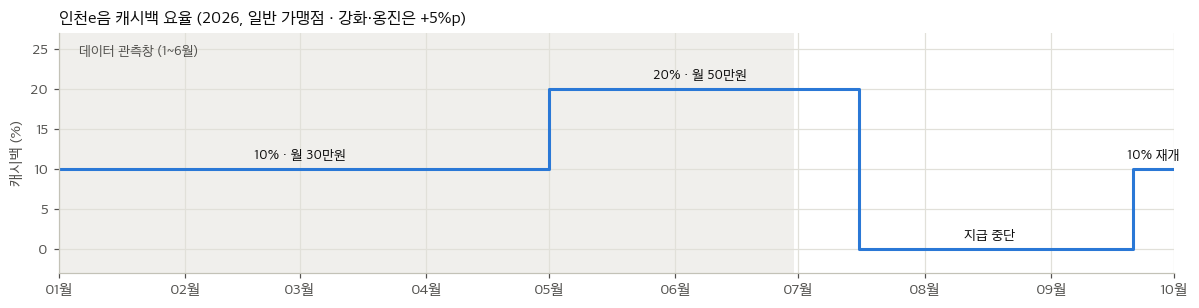

In [25]:
# 캐시백 요율 타임라인 (일반 가맹점) — 데이터 관측창과의 관계
D = dt.date
steps = [(D(2026, 1, 1), 10), (D(2026, 5, 1), 20), (D(2026, 7, 16), 0), (D(2026, 9, 21), 10), (D(2026, 10, 1), 10)]
fig, ax = plt.subplots(figsize=(11, 2.9))
ax.step([d for d, _ in steps], [r for _, r in steps], where="post", color=C["인천"])
ax.axvspan(D(2026, 1, 1), D(2026, 6, 30), color=C["wash"], zorder=0, lw=0)
ax.text(D(2026, 1, 6), 25.5, "데이터 관측창 (1~6월)", fontsize=9, color=C["ink2"], va="top")
for d, r, t in [(D(2026, 3, 1), 10, "10% · 월 30만원"), (D(2026, 6, 7), 20, "20% · 월 50만원"),
                (D(2026, 8, 17), 0, "지급 중단"), (D(2026, 9, 26), 10, "10% 재개")]:
    ax.annotate(t, (d, r), xytext=(0, 6), textcoords="offset points", ha="center", fontsize=9, color=C["ink"])
ax.set_xlim(D(2026, 1, 1), D(2026, 10, 1)); ax.set_ylim(-3, 27); ax.set_ylabel("캐시백 (%)")
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%m월"))
ax.set_title("인천e음 캐시백 요율 (2026, 일반 가맹점 · 강화·옹진은 +5%p)")
plt.tight_layout(); plt.show()

## B3. 인천 프로파일 — 규모와 구성이 전국과 얼마나 다른가
전국을 대조군으로 쓰려면 인천의 소비 구성이 전국과 크게 다르지 않아야 한다.

인천 결제금액 0.81조원 · 전국의 4.7% (17개 시도 중 7위)
인천 결제건수 0.47억 건 · 객단가 17,213원 (전국 18,149원)


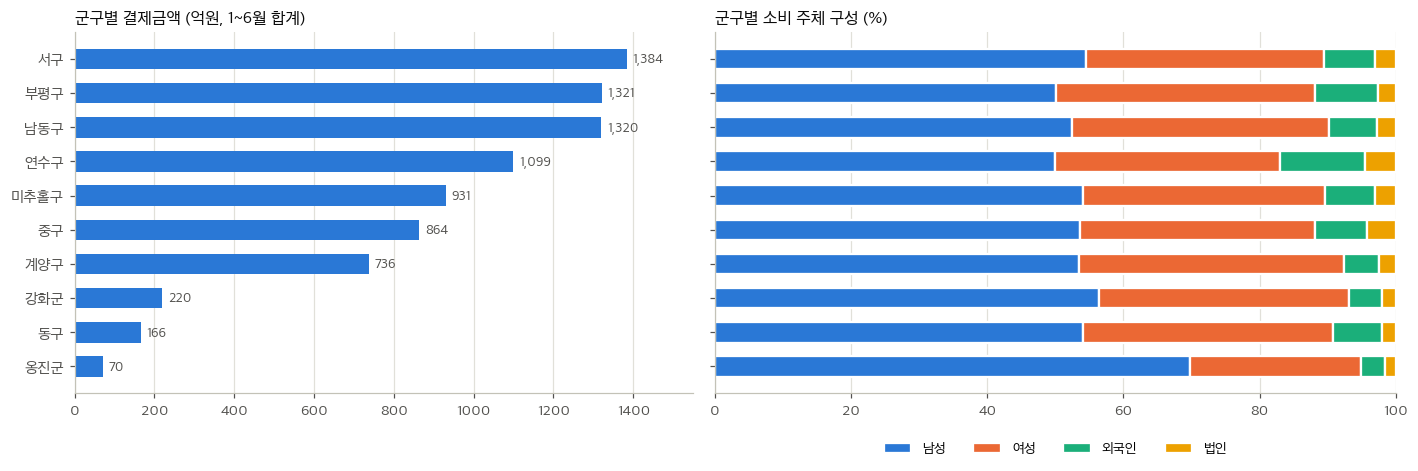

In [26]:
tot_amt, tot_cnt = df.amt.sum(), df.cnt.sum()
sido = df.groupby("SIDO_NM").agg(amt=("amt", "sum"), cnt=("cnt", "sum"))
rank_amt = int(sido.amt.rank(ascending=False)["인천광역시"])
print(f"인천 결제금액 {ic_all.amt.sum()/1e12:.2f}조원 · 전국의 {ic_all.amt.sum()/tot_amt*100:.1f}% (17개 시도 중 {rank_amt}위)")
print(f"인천 결제건수 {ic_all.cnt.sum()/1e8:.2f}억 건 · 객단가 {ic_all.amt.sum()/ic_all.cnt.sum():,.0f}원 (전국 {tot_amt/tot_cnt:,.0f}원)")

# 군구별 규모와 소비 주체 구성
g = ic_all.pivot_table(index="CCG_NM", columns="seg", values="amt", aggfunc="sum").fillna(0)[["남성", "여성", "외국인", "법인"]]
g = g.loc[g.sum(axis=1).sort_values().index]
tot = g.sum(axis=1) / EOK
share = g.div(g.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.1]})
ax = axes[0]
ax.barh(g.index, tot, color=C["인천"], height=0.6)
for i, v in enumerate(tot):
    ax.text(v + tot.max() * 0.01, i, f"{v:,.0f}", va="center", fontsize=9, color=C["ink2"])
ax.set_xlim(0, tot.max() * 1.12); ax.grid(axis="y", visible=False)
ax.set_title("군구별 결제금액 (억원, 1~6월 합계)")
ax = axes[1]
left = np.zeros(len(share))
for s, col in zip(share.columns, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]):
    ax.barh(share.index, share[s], left=left, color=col, height=0.6, label=s, edgecolor="white", linewidth=1.5)
    left += share[s].values
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False); ax.set_yticklabels([])
ax.set_title("군구별 소비 주체 구성 (%)"); ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1))
plt.tight_layout(); plt.show()

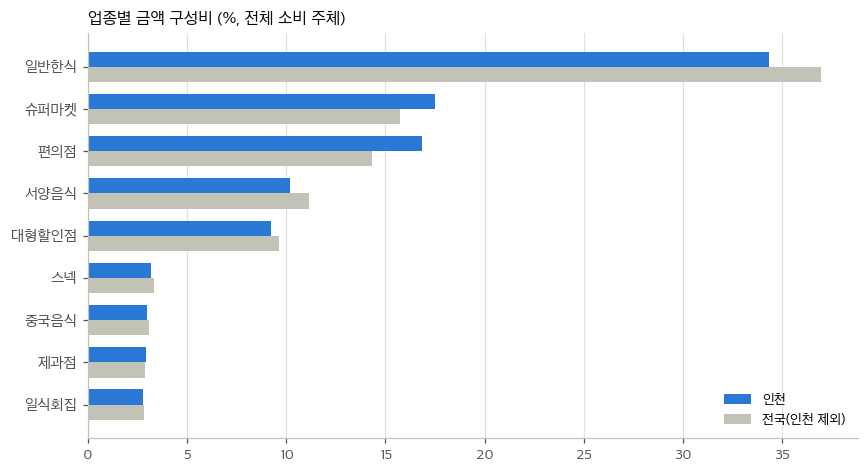

인천  전국(인천 제외)
소비 주체 구성 (%)      남성     52.8       51.0
                  여성     36.1       35.3
                  외국인     8.0        7.4
                  법인      3.1        6.3
연령 구성 (%, 내국인 개인) 20대 이하  1.0        1.0
                  20대     8.4        8.9
                  30대    15.2       15.2
                  40대    22.0       21.6
                  50대    25.8       26.0
                  60대 이상 27.6       27.4

In [27]:
def share_by(d, by):
    s = d.groupby(by).amt.sum(); return s / s.sum() * 100

comp = pd.DataFrame({"인천": share_by(ic_all, "biz"), "전국(인천 제외)": share_by(df[~df.is_ic], "biz")}).fillna(0)
comp = comp[comp.max(axis=1) >= 0.5].sort_values("전국(인천 제외)")          # 갈비전문점·한정식 제외

fig, ax = plt.subplots(figsize=(8, 4.4))
y = np.arange(len(comp)); h = 0.36
ax.barh(y + h / 2, comp["인천"], height=h, color=C["인천"], label="인천")
ax.barh(y - h / 2, comp["전국(인천 제외)"], height=h, color=C["ref"], label="전국(인천 제외)")
ax.set_yticks(y); ax.set_yticklabels(comp.index); ax.grid(axis="y", visible=False)
ax.set_title("업종별 금액 구성비 (%, 전체 소비 주체)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

seg_c = pd.DataFrame({"인천": share_by(ic_all, "seg"), "전국(인천 제외)": share_by(df[~df.is_ic], "seg")}).reindex(["남성", "여성", "외국인", "법인"])
age_c = pd.DataFrame({"인천": share_by(icn, "age"), "전국(인천 제외)": share_by(nat, "age")}).reindex(AGE_ORDER)
display(pd.concat({"소비 주체 구성 (%)": seg_c, "연령 구성 (%, 내국인 개인)": age_c}).round(1))

- 인천은 전국 결제금액의 4.7%(7위). **업종·연령 구성은 전국과 거의 같다**(일반한식 35% 안팎, 60대 이상 27% 등) → 전국·타 광역시를 대조군으로 쓰기에 구성 차이가 작다.
- 다른 점은 둘: **법인 비중이 낮고**(3.1% vs 6.3%), **동구는 대형할인점이 34%** 로 튄다. 법인은 어차피 e음을 쓸 수 없으므로 분석 기준은 내국인 개인으로 잡는다.

## B4. 시계열 — 인천 vs 전국: 언제부터 갈라지는가
규모가 다른 집단을 한 축에 놓기 위해 **1~4월 평균 = 100 지수**로 비교한다. 음영은 캐시백 20% 기간.

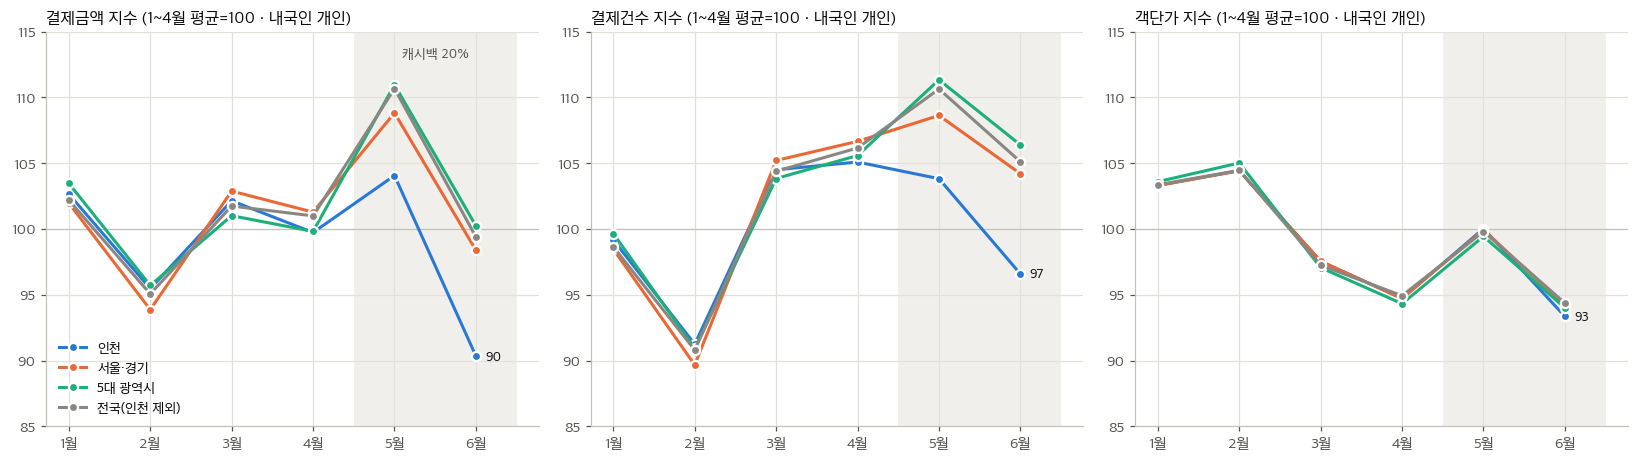

,금액 지수 5월,금액 지수 6월,금액 변화율 (5~6월 vs 1~4월),건수 변화율,객단가 변화율
인천,104.1,90.3,-2.8,0.2,-3.3
서울·경기,108.8,98.4,3.6,6.4,-2.9
5대 광역시,111.0,100.2,5.6,8.9,-3.3
전국(인천 제외),110.7,99.4,5.0,7.9,-2.9


In [28]:
GROUPS = {"인천": icn,
          "서울·경기": nat[nat.SIDO_NM.isin(["서울특별시", "경기도"])],
          "5대 광역시": nat[nat.SIDO_NM.isin(BIG5)],
          "전국(인천 제외)": nat}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (col, title) in zip(axes, [("amt", "결제금액"), ("cnt", "결제건수"), ("unit", "객단가")]):
    for name, d in GROUPS.items():
        s = munit(d) if col == "unit" else msum(d, col)
        line(ax, idx(s), name, label_end=(name == "인천"))
    shade(ax); ax.set_ylim(85, 115)
    ax.set_title(f"{title} 지수 (1~4월 평균=100 · 내국인 개인)")
axes[0].legend(loc="lower left"); axes[0].text(4.5, 113, "캐시백 20%", ha="center", fontsize=9, color=C["ink2"])
plt.tight_layout(); plt.show()

tab = {name: {"금액 지수 5월": idx(msum(d)).loc[202605], "금액 지수 6월": idx(msum(d)).loc[202606],
              "금액 변화율 (5~6월 vs 1~4월)": pp_total(d), "건수 변화율": pp_total(d, "cnt"),
              "객단가 변화율": (munit(d).loc[POST].mean() / munit(d).loc[PRE].mean() - 1) * 100}
       for name, d in GROUPS.items()}
display(pd.DataFrame(tab).T.round(1))

- 1~4월엔 네 집단이 ±1pt 안에서 같이 움직인다. **5월부터 인천만 처진다**(금액 104 vs 109~111) — 5월은 전국적으로 소비 피크인데 인천은 피크가 작고, **6월은 90 vs 98~100**으로 격차가 더 벌어진다.
- 건수도 같은 방향이고 **객단가는 차이가 없다** → 빠진 것은 "결제 건수"다. 결제 수단이 카드에서 e음으로 옮겨 갔다는 해석과 부합한다.

## B5. 사전 추세 검증과 반사실 갭 — "얼마나" 빠졌나
전국(인천 제외) 추세를 인천의 1~4월 수준에 적용한 값을 **반사실(counterfactual)** 로 두고, 실제와의 갭을 월별로 본다.
1~3월 갭이 0 근처면 평행 추세 가정이 성립한다.

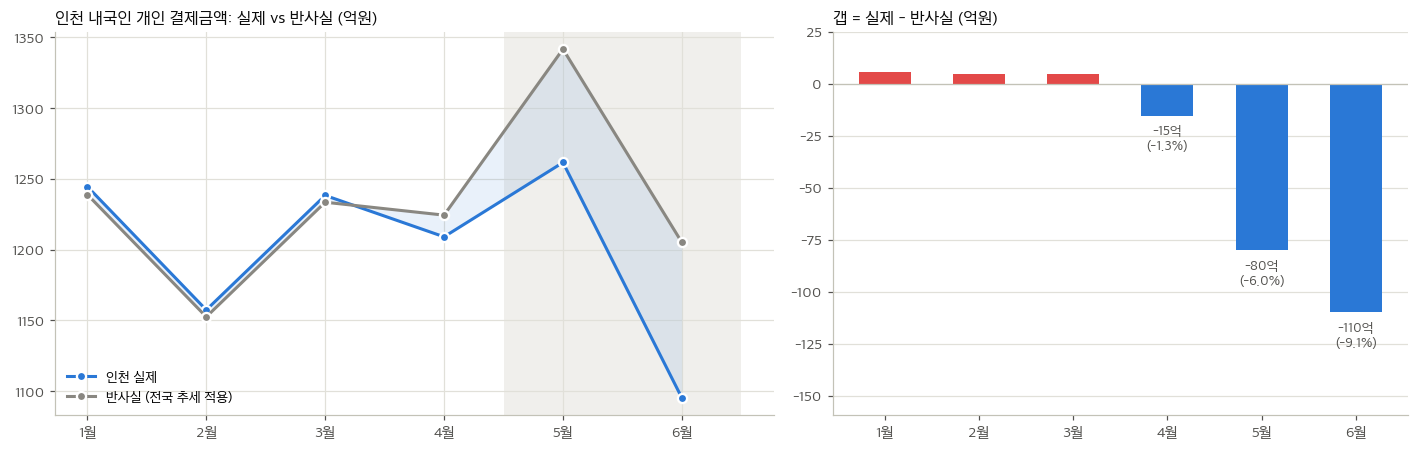

5~6월 갭 합계 -190억원  (5월 -6.0% · 6월 -9.1%)


STRD_YYMM,202601,202602,202603,202604,202605,202606
실제(억),"1,244.6","1,157.4","1,238.3","1,209.1","1,261.6","1,095.3"
반사실(억),"1,238.9","1,152.5","1,233.5","1,224.4","1,341.7","1,205.1"
갭(억),5.6,4.9,4.8,-15.3,-80.1,-109.9
갭(%),0.5,0.4,0.4,-1.3,-6.0,-9.1


In [29]:
ic_m, nat_m = msum(icn), msum(nat)
cf  = ic_m.loc[PRE].mean() * nat_m / nat_m.loc[PRE].mean()
gap = ic_m - cf; gap_pct = gap / cf * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
ax.plot(range(6), ic_m / EOK, marker="o", color=C["인천"], mec="white", mew=1.5, label="인천 실제", zorder=3)
ax.plot(range(6), cf / EOK, marker="o", color=C["전국(인천 제외)"], mec="white", mew=1.5, label="반사실 (전국 추세 적용)", zorder=3)
ax.fill_between(range(6), ic_m / EOK, cf / EOK, color=C["인천"], alpha=0.10, lw=0)
ax.axvspan(3.5, 5.5, color=C["wash"], zorder=0, lw=0); ax.set_xticks(range(6)); ax.set_xticklabels(MLAB)
ax.set_title("인천 내국인 개인 결제금액: 실제 vs 반사실 (억원)"); ax.legend(loc="lower left")
ax = axes[1]
ax.bar(range(6), gap / EOK, color=[C["인천"] if v < 0 else C["up"] for v in gap], width=0.55)
for i, (v, p) in enumerate(zip(gap / EOK, gap_pct)):
    if abs(p) >= 1:
        ax.text(i, v - 4, f"{v:,.0f}억\n({p:+.1f}%)", ha="center", va="top", fontsize=9, color=C["ink2"])
ax.axhline(0, color=C["ref"], lw=0.8); ax.set_xticks(range(6)); ax.set_xticklabels(MLAB)
ax.set_ylim(gap.min() / EOK * 1.45, 25); ax.grid(axis="x", visible=False)
ax.set_title("갭 = 실제 - 반사실 (억원)")
plt.tight_layout(); plt.show()

print(f"5~6월 갭 합계 {gap.loc[POST].sum()/EOK:,.0f}억원  (5월 {gap_pct.loc[202605]:+.1f}% · 6월 {gap_pct.loc[202606]:+.1f}%)")
display(pd.DataFrame({"실제(억)": ic_m / EOK, "반사실(억)": cf / EOK, "갭(억)": gap / EOK, "갭(%)": gap_pct}).round(1).T)

In [30]:
# 강건성 ① 대조군을 바꿔도 갭이 유지되는가
rows = {}
for name, d in {"전국(인천 제외)": nat, "서울·경기": GROUPS["서울·경기"], "5대 광역시": GROUPS["5대 광역시"]}.items():
    r = msum(d); c = ic_m.loc[PRE].mean() * r / r.loc[PRE].mean(); g_ = ic_m - c
    rows[name] = {"4월 갭%": (g_ / c * 100).loc[202604], "5월 갭%": (g_ / c * 100).loc[202605],
                  "6월 갭%": (g_ / c * 100).loc[202606], "5~6월 갭(억원)": g_.loc[POST].sum() / EOK}
display(pd.DataFrame(rows).T.round(1))

# 강건성 ② 균형패널 — 6개월 모두 수록된 셀만으로 다시 계산 (셀 출입에 의한 착시 배제)
b_ic, b_nat = msum(icn[icn.n_month == 6]), msum(nat[nat.n_month == 6])
b_cf = b_ic.loc[PRE].mean() * b_nat / b_nat.loc[PRE].mean()
print("균형패널 금액 커버리지:", f"{b_ic.sum()/ic_m.sum()*100:.1f}%", "· 갭%:", ((b_ic - b_cf) / b_cf * 100).round(1).to_dict())

,4월 갭%,5월 갭%,6월 갭%,5~6월 갭(억원)
전국(인천 제외),-1.3,-6.0,-9.1,-190.0
서울·경기,-1.5,-4.4,-8.2,-155.3
5대 광역시,-0.1,-6.2,-9.9,-203.6


균형패널 금액 커버리지: 100.0% · 갭%: {202601: 0.5, 202602: 0.4, 202603: 0.4, 202604: -1.3, 202605: -6.0, 202606: -9.1}


- **1~3월 갭 +0.4~0.5%** → 평행 추세 성립. **4월 -1.3%** 는 4/14 발표 이후 소비를 5월로 미룬 이연 효과일 수 있다(본분석에서 4월을 사전 기간에서 빼고 재확인).
- **5월 -6.0%, 6월 -9.1%, 두 달 합계 약 -190억원**(내국인 개인, BC카드 기준). 대조군을 서울·경기, 5대 광역시로 바꿔도 -4~-10%로 유지되고, 균형패널에서도 같다.
- 6월이 5월보다 큰 것은 e음 가입·충전이 5월에 폭증한 뒤 6월에 사용이 본격화된 흐름과 맞는다. 7월(중단)이 데이터에 없는 것이 아쉽다.

## B6. 전국 속 인천의 위치 — 우연히 낮은 것인가
5~6월 vs 1~4월 변화율을 시도·시군구 단위로 늘어놓고 인천이 어디에 있는지 본다.

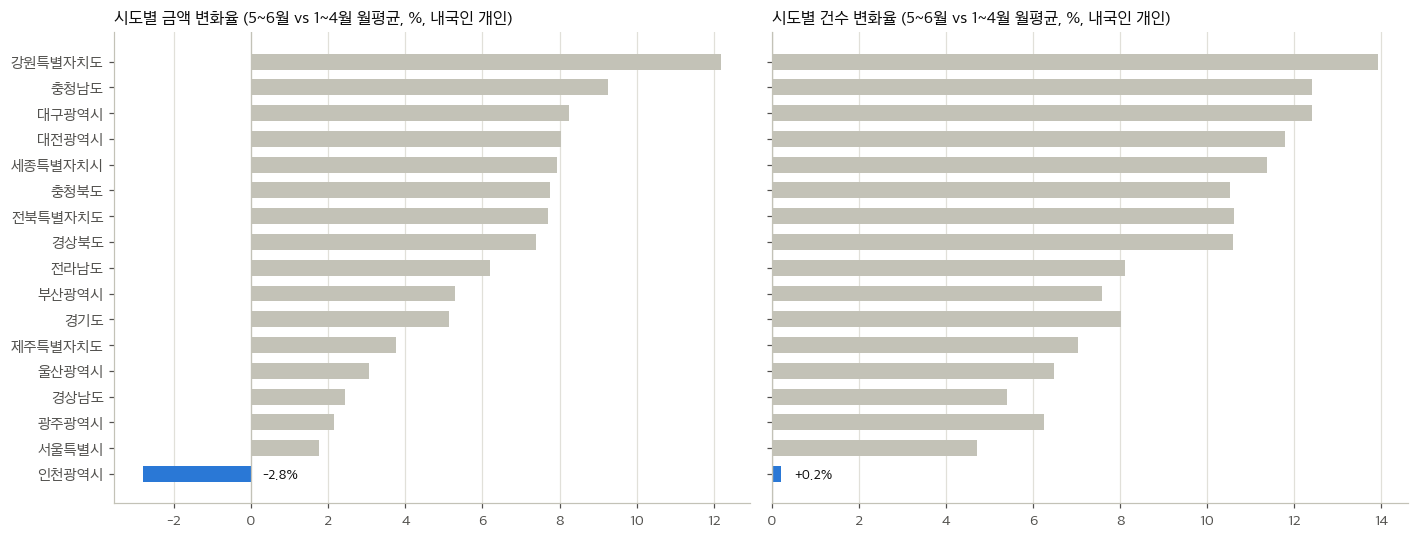

In [31]:
sd = pd.DataFrame({"금액": prepost(ind, "SIDO_NM"), "건수": prepost(ind, "SIDO_NM", "cnt")}).sort_values("금액")
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, col in zip(axes, ["금액", "건수"]):
    ax.barh(sd.index, sd[col], color=[C["인천"] if s == "인천광역시" else C["ref"] for s in sd.index], height=0.62)
    v = sd.loc["인천광역시", col]; i = list(sd.index).index("인천광역시")
    ax.text(0.3 if v < 0 else v + 0.3, i, f"{v:+.1f}%", ha="left", va="center", fontsize=9, color=C["ink"])
    ax.axvline(0, color=C["ref"], lw=0.8); ax.grid(axis="y", visible=False)
    ax.set_title(f"시도별 {col} 변화율 (5~6월 vs 1~4월 월평균, %, 내국인 개인)")
plt.tight_layout(); plt.show()

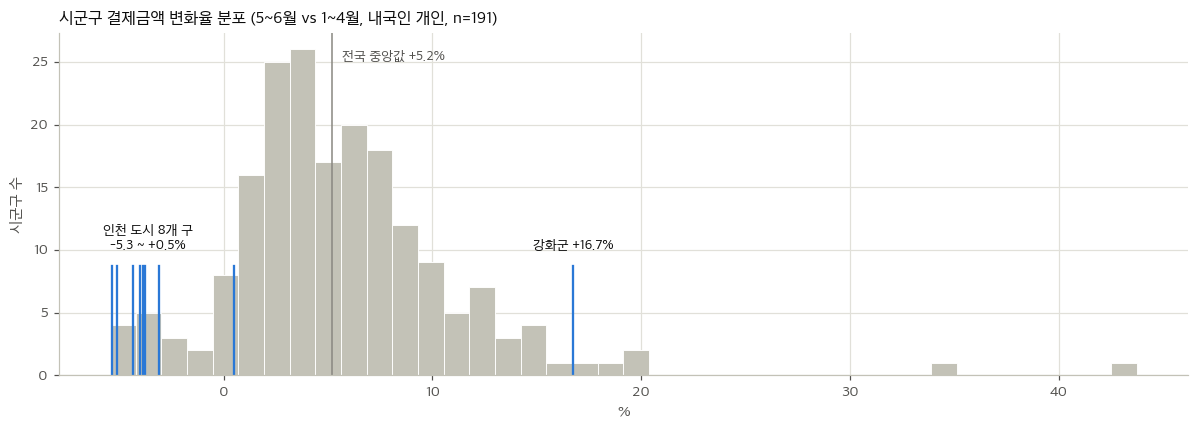

,변화율 %,"전국 순위 (낮은 순, n=191)"
region,,
인천광역시 계양구,-5.3,2
인천광역시 남동구,-5.1,3
인천광역시 연수구,-4.3,4
인천광역시 서구,-4.0,6
인천광역시 동구,-3.9,7
인천광역시 미추홀구,-3.7,8
인천광역시 부평구,-3.1,9
인천광역시 중구,0.5,20
인천광역시 강화군,16.7,186


In [32]:
pre_reg = ind[ind.STRD_YYMM.isin(PRE)].groupby("region").amt.sum() / len(PRE)
reg_pp  = prepost(ind, "region")
reg_pp  = reg_pp[pre_reg >= pre_reg.quantile(0.25)]             # 규모 하위 25% 제외 (옹진군 포함) — 소규모 노이즈 차단
ic_pp   = reg_pp[reg_pp.index.str.startswith("인천")].sort_values()
urban   = ic_pp[~ic_pp.index.str.contains("강화군|옹진군")]

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(reg_pp, bins=40, color=C["ref"], edgecolor="white", linewidth=0.6)
ymax = ax.get_ylim()[1]
ax.axvline(reg_pp.median(), color=C["muted"], lw=1)
ax.text(reg_pp.median() + 0.5, ymax * 0.95, f"전국 중앙값 {reg_pp.median():+.1f}%", fontsize=9, color=C["ink2"], va="top")
for r, v in ic_pp.items():
    ax.axvline(v, color=C["인천"], lw=1.5, ymax=0.32)
ax.annotate(f"인천 도시 8개 구\n{urban.min():+.1f} ~ {urban.max():+.1f}%", (urban.mean(), ymax * 0.36), ha="center", va="bottom", fontsize=9, color=C["ink"])
for r in [x for x in ["인천광역시 강화군", "인천광역시 옹진군"] if x in ic_pp.index]:
    ax.annotate(f"{r.split()[-1]} {ic_pp[r]:+.1f}%", (ic_pp[r], ymax * 0.36), ha="center", va="bottom", fontsize=9, color=C["ink"])
ax.set_xlabel("%"); ax.set_ylabel("시군구 수")
ax.set_title(f"시군구 결제금액 변화율 분포 (5~6월 vs 1~4월, 내국인 개인, n={len(reg_pp)})")
plt.tight_layout(); plt.show()

rk = reg_pp.rank().astype(int)
display(pd.DataFrame({"변화율 %": ic_pp, f"전국 순위 (낮은 순, n={len(reg_pp)})": rk[ic_pp.index]}).round(1))

- 인천은 17개 시도 중 **유일한 마이너스**(금액 -2.8%)이고, 건수도 유일하게 0 근처다. 두 번째로 낮은 서울과도 4~5pt 차이.
- 시군구로 내려가면 **도시 8개 구 중 7개가 전국 191곳 중 하위 9위 안**에 몰려 있다. 개별 상권의 문제가 아니라 **도시 단위 충격**이다.
- **정의를 바꾸면 '유일한 음수'는 흔들리지만 '최하위'는 유지된다** (시도 기준):

  | 정의 | 음수 시도 |
  |---|---|
  | 금액·개인·5~6월 vs 1~4월 (기본) | 인천만 (-2.8) |
  | 금액·전체 주체 | 인천만 (-2.1) |
  | 4~6월 vs 1~3월 | 인천만 (-2.0) |
  | 건수·개인 | 없음 |
  | 5월만 | 없음 |
  | 6월만 | 9곳 — 인천 -9.7 최하위, 2위 경남 -3.4 |

  → 보고서 표현은 "유일한 마이너스"보다 **"17개 시도 중 최하위"** 가 안전하다.
- 규모 필터 없이 전체 255개 시군구를 보면 음수는 20곳, 그중 인천 7곳. 나머지는 무주·양산·홍성·강남·금천·창원 진해·영덕·목포·수원 장안·마포·광주 서구·부천 소사 등 흩어져 있다.

## B7. 업종별 — e음을 쓸 수 있는 업종에서만 빠지는가 (플라시보 검정)
대형할인점(대형마트·SSM)은 e음 결제가 안 된다. 대체효과라면 **대형할인점의 인천-전국 격차는 0 근처**여야 하고, 소상공인 업종에서만 격차가 나야 한다.

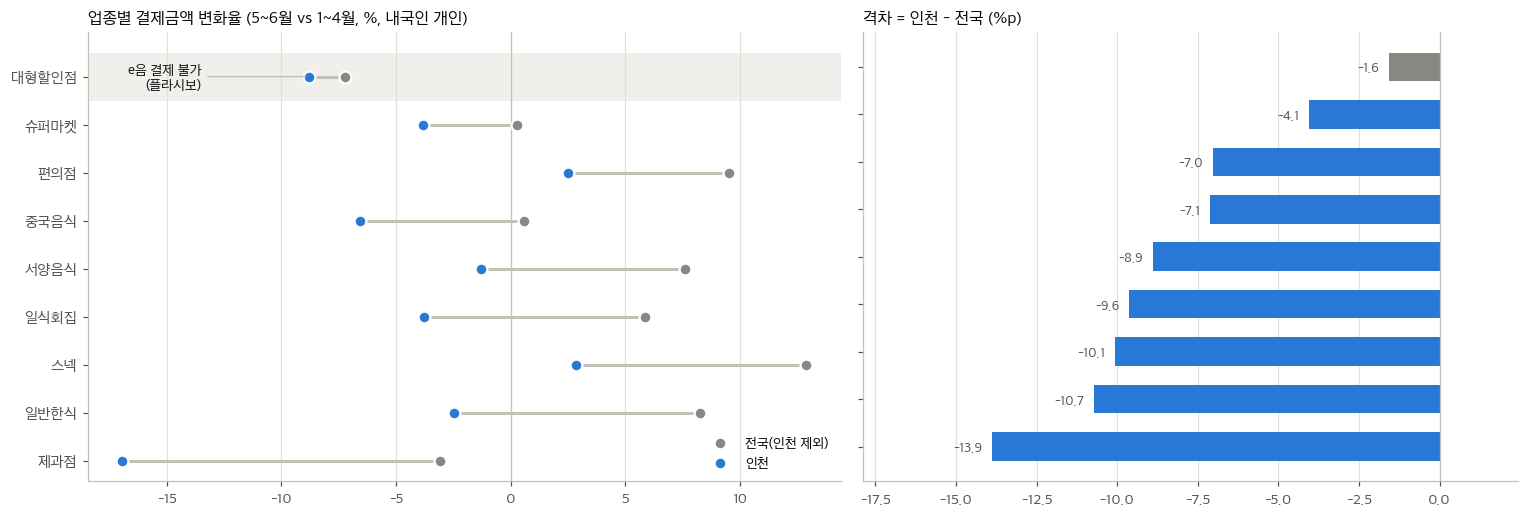

,인천 금액(억),인천,전국(인천 제외),격차(금액),인천 건수,전국 건수,격차(건수)
biz,,,,,,,
제과점,200.3,-16.9,-3.1,-13.9,-11.6,0.3,-11.8
일반한식,"2,557.7",-2.5,8.2,-10.7,-2.9,7.7,-10.6
스넥,234.7,2.8,12.9,-10.1,-1.3,8.4,-9.7
일식회집,208.2,-3.8,5.9,-9.6,-1.9,8.4,-10.4
서양음식,705.1,-1.3,7.6,-8.9,3.8,11.9,-8.1
중국음식,210.7,-6.6,0.6,-7.1,-6.0,1.3,-7.3
편의점,"1,183.0",2.5,9.5,-7.0,4.1,11.1,-7.0
슈퍼마켓,"1,236.1",-3.8,0.3,-4.1,-2.7,3.7,-6.4
대형할인점,669.8,-8.8,-7.2,-1.6,-6.3,-4.5,-1.8


In [33]:
biz_amt = icn.groupby("biz").amt.sum() / EOK
bz = pd.DataFrame({"인천 금액(억)": biz_amt,
                   "인천": prepost(icn, "biz"), "전국(인천 제외)": prepost(nat, "biz"),
                   "인천 건수": prepost(icn, "biz", "cnt"), "전국 건수": prepost(nat, "biz", "cnt")})
bz["격차(금액)"] = bz["인천"] - bz["전국(인천 제외)"]; bz["격차(건수)"] = bz["인천 건수"] - bz["전국 건수"]
bz = bz[bz["인천 금액(억)"] >= 10].sort_values("격차(금액)")       # 갈비전문점·한정식(인천 1억 미만) 제외
PLACEBO = "대형할인점"

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
y = np.arange(len(bz)); i_p = list(bz.index).index(PLACEBO)
ax = axes[0]
ax.axhspan(i_p - 0.5, i_p + 0.5, color=C["wash"], zorder=0, lw=0)
ax.hlines(y, bz["전국(인천 제외)"], bz["인천"], color=C["ref"], lw=2, zorder=2)
ax.scatter(bz["전국(인천 제외)"], y, s=60, color=C["전국(인천 제외)"], ec="white", lw=1.5, zorder=3, label="전국(인천 제외)")
ax.scatter(bz["인천"], y, s=60, color=C["인천"], ec="white", lw=1.5, zorder=3, label="인천")
ax.annotate("e음 결제 불가\n(플라시보)", (bz.loc[PLACEBO, "인천"], i_p), xytext=(-70, 0), textcoords="offset points",
            va="center", ha="right", fontsize=9, color=C["ink"], arrowprops=dict(arrowstyle="-", color=C["ref"]))
ax.set_yticks(y); ax.set_yticklabels(bz.index); ax.axvline(0, color=C["ref"], lw=0.8); ax.grid(axis="y", visible=False)
ax.set_title("업종별 결제금액 변화율 (5~6월 vs 1~4월, %, 내국인 개인)"); ax.legend(loc="lower right")
ax = axes[1]
ax.barh(y, bz["격차(금액)"], color=[C["muted"] if b == PLACEBO else C["인천"] for b in bz.index], height=0.6)
for i, v in enumerate(bz["격차(금액)"]):
    ax.text(v - 0.3 if v < 0 else v + 0.3, i, f"{v:+.1f}", va="center", ha="right" if v < 0 else "left", fontsize=9, color=C["ink2"])
ax.set_yticks(y); ax.set_yticklabels([]); ax.axvline(0, color=C["ref"], lw=0.8); ax.grid(axis="y", visible=False)
ax.set_xlim(bz["격차(금액)"].min() - 4, bz["격차(금액)"].max() + 4)
ax.set_title("격차 = 인천 - 전국 (%p)")
plt.tight_layout(); plt.show()

display(bz[["인천 금액(억)", "인천", "전국(인천 제외)", "격차(금액)", "인천 건수", "전국 건수", "격차(건수)"]].round(1))

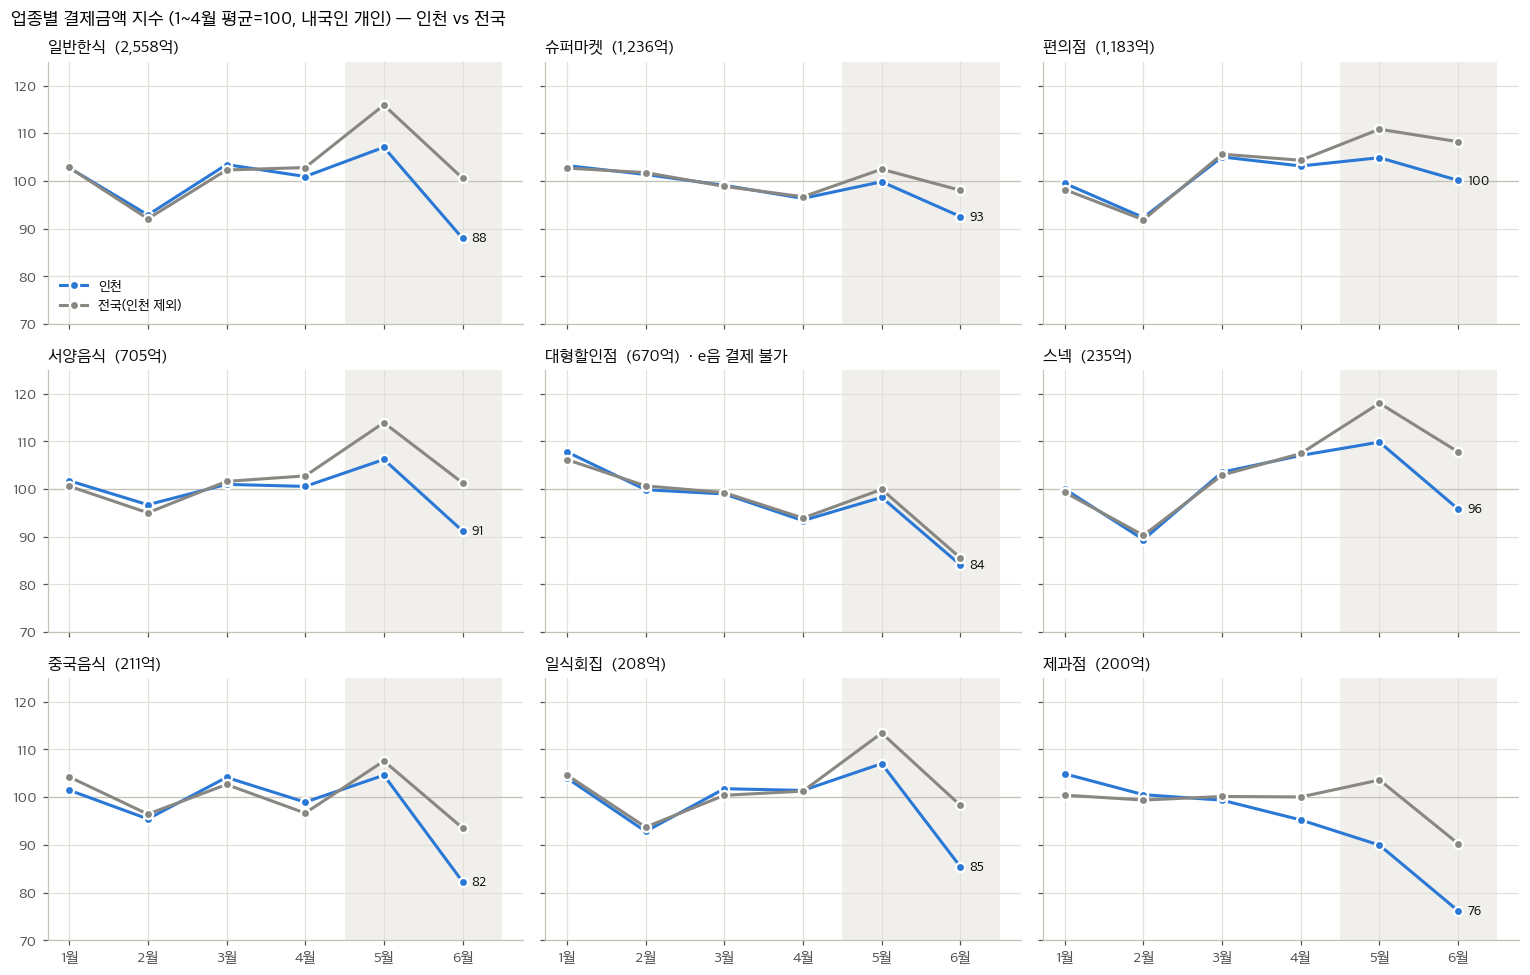

In [34]:
top9 = biz_amt.sort_values(ascending=False).index[:9]
fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True, sharey=True)
for ax, b in zip(axes.flat, top9):
    line(ax, idx(msum(icn[icn.biz == b])), "인천")
    line(ax, idx(msum(nat[nat.biz == b])), "전국(인천 제외)", label_end=False)
    shade(ax); ax.set_title(f"{b}  ({biz_amt[b]:,.0f}억)" + ("  · e음 결제 불가" if b == PLACEBO else ""))
axes[0, 0].set_ylim(70, 125); axes[0, 0].legend(loc="lower left")
fig.suptitle("업종별 결제금액 지수 (1~4월 평균=100, 내국인 개인) — 인천 vs 전국", x=0.01, ha="left", fontsize=12, fontweight="semibold")
plt.tight_layout(); plt.show()

- **대형할인점(e음 불가) 격차 -1.6pt ≈ 0.** 인천도 전국도 5~6월에 똑같이 빠졌다(계절 요인). 반면 **소상공인 업종은 -7~-14pt** — 제과점·일반한식·스넥·일식회집·서양음식 순으로 크다.
- 격차의 크기가 **e음 적격성과 맞아떨어지는 것**이 이 EDA에서 가장 강한 대체효과 증거다. 슈퍼마켓 격차(-4pt)가 작은 것은 SSM(e음 불가)이 섞여 있기 때문으로 보인다.
- 지수 그림에서 인천 소상공인 업종은 5월 피크가 작고 6월 낙폭이 크다. 대형할인점은 두 선이 겹친다.

## B8. 군구별 — 도시 8개 구 vs 강화·옹진
강화·옹진은 캐시백이 25%로 더 높지만, 소비의 주체가 관광객(비인천 거주자)이라 e음 대체가 일어나기 어렵다. 따로 봐야 한다.

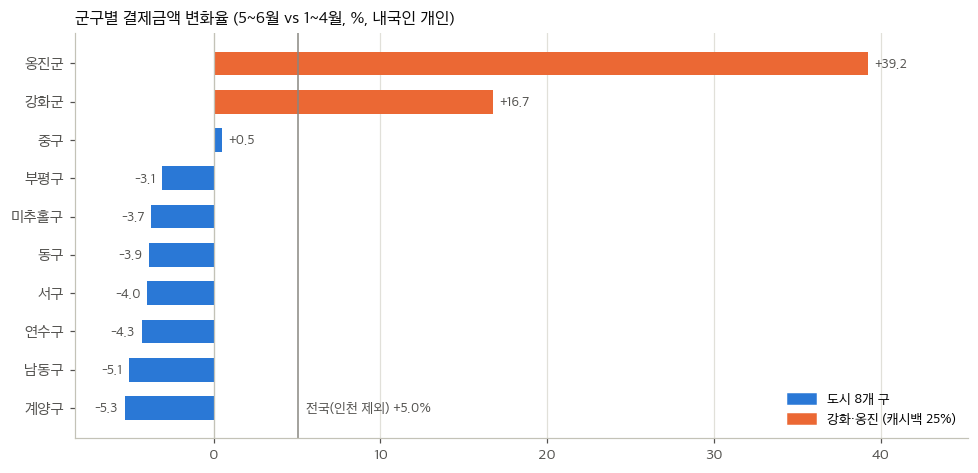

CCG_NM,계양구,남동구,연수구,서구,동구,미추홀구,부평구,중구,강화군,옹진군
변화율,-5.3,-5.1,-4.3,-4.0,-3.9,-3.7,-3.1,0.5,16.7,39.2
금액(억),680.8,"1,191.4",912.2,"1,239.2",150.3,834.8,"1,165.3",761.5,204.4,66.3


In [35]:
ccg = pd.DataFrame({"변화율": prepost(icn, "CCG_NM"), "금액(억)": icn.groupby("CCG_NM").amt.sum() / EOK}).sort_values("변화율")
ref_nat = pp_total(nat); ISLAND = ("강화군", "옹진군")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(ccg.index, ccg["변화율"], color=[C["서울·경기"] if c in ISLAND else C["인천"] for c in ccg.index], height=0.62)
for i, v in enumerate(ccg["변화율"]):
    ax.text(v + 0.4 if v >= 0 else v - 0.4, i, f"{v:+.1f}", va="center", ha="left" if v >= 0 else "right", fontsize=9, color=C["ink2"])
ax.axvline(0, color=C["ref"], lw=0.8); ax.axvline(ref_nat, color=C["muted"], lw=1)
ax.text(ref_nat + 0.5, 0, f"전국(인천 제외) {ref_nat:+.1f}%", fontsize=9, color=C["ink2"], va="center")
ax.set_xlim(ccg["변화율"].min() - 3, ccg["변화율"].max() + 6); ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=C["인천"], label="도시 8개 구"), Patch(color=C["서울·경기"], label="강화·옹진 (캐시백 25%)")], loc="lower right")
ax.set_title("군구별 결제금액 변화율 (5~6월 vs 1~4월, %, 내국인 개인)")
plt.tight_layout(); plt.show()
display(ccg.round(1).T)

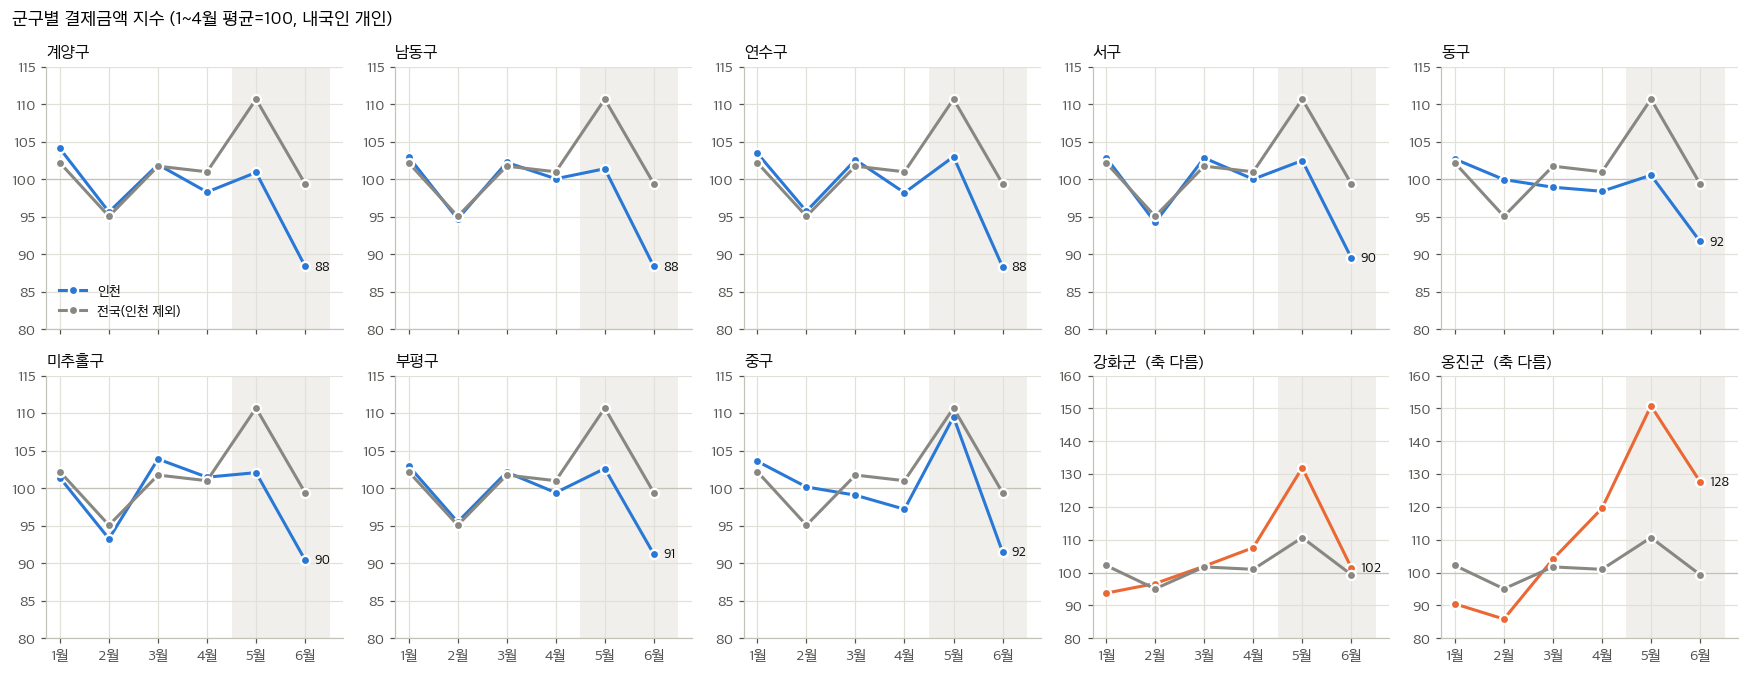

In [36]:
order = ["계양구", "남동구", "연수구", "서구", "동구", "미추홀구", "부평구", "중구", "강화군", "옹진군"]
nat_idx = idx(msum(nat))
fig, axes = plt.subplots(2, 5, figsize=(16, 6.2), sharex=True)
for ax, c in zip(axes.flat, order):
    line(ax, idx(msum(icn[icn.CCG_NM == c])), "인천", color=C["서울·경기"] if c in ISLAND else C["인천"])
    line(ax, nat_idx, "전국(인천 제외)", label_end=False)
    shade(ax); ax.set_ylim((80, 160) if c in ISLAND else (80, 115))
    ax.set_title(c + ("  (축 다름)" if c in ISLAND else ""))
axes[0, 0].legend(loc="lower left")
fig.suptitle("군구별 결제금액 지수 (1~4월 평균=100, 내국인 개인)", x=0.01, ha="left", fontsize=12, fontweight="semibold")
plt.tight_layout(); plt.show()

In [37]:
# 강화·옹진의 상승은 정책 효과가 아니라 전국 군(郡) 단위의 봄 관광 계절성과 같은 패턴인가
typ = pd.Series(np.where(reg_pp.index.str.endswith("군"), "군", "시·구"), index=reg_pp.index)
print("유형별 변화율 중앙값(%):", reg_pp.groupby(typ).median().round(1).to_dict())
gun = reg_pp[typ == "군"].sort_values(ascending=False)
display(pd.DataFrame({"변화율 %": gun.head(10), "군 중 순위": gun.rank(ascending=False).astype(int).head(10)}).round(1).T)
print(f"강화군: {gun['인천광역시 강화군']:+.1f}% (군 {len(gun)}곳 중 {int(gun.rank(ascending=False)['인천광역시 강화군'])}위) · 옹진군은 규모 필터로 분포에서 제외 (원자료 {ccg.loc['옹진군', '변화율']:+.1f}%)")

유형별 변화율 중앙값(%): {'군': 12.1, '시·구': 4.2}


region,충청남도 태안군,경기도 가평군,경상남도 남해군,경기도 양평군,인천광역시 강화군,경상남도 함안군,전라남도 담양군,전라남도 해남군,강원특별자치도 홍천군,전라남도 무안군
변화율 %,43.7,34.9,20.2,19.3,16.7,14.9,14.7,12.6,12.4,12.3
군 중 순위,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0


강화군: +16.7% (군 21곳 중 5위) · 옹진군은 규모 필터로 분포에서 제외 (원자료 +39.2%)


- **도시 8개 구 중 7곳이 -3.1 ~ -5.3%로 고르게** 빠졌다(중구만 +0.5%). 특정 상권이 아니라 시 전체가 같은 방향 → 시 단위 정책 충격과 부합.
- **강화·옹진은 +17%, +39%.** 캐시백이 가장 높은 곳인데도 오른 것은, 이곳 카드소비가 방문객 중심이고 전국 군 단위가 봄에 +12%(중앙값) 오르는 관광 계절성을 그대로 따르기 때문이다. 본분석에서는 처치군에서 분리한다.

## B9. 소비 주체·연령·성별 — 누가 갈아탔나
법인카드는 e음을 쓸 수 없고, 외국인은 외국인등록증으로 가입할 수 있다. 개인은 성별·연령을 가리지 않고 빠졌는지 본다.

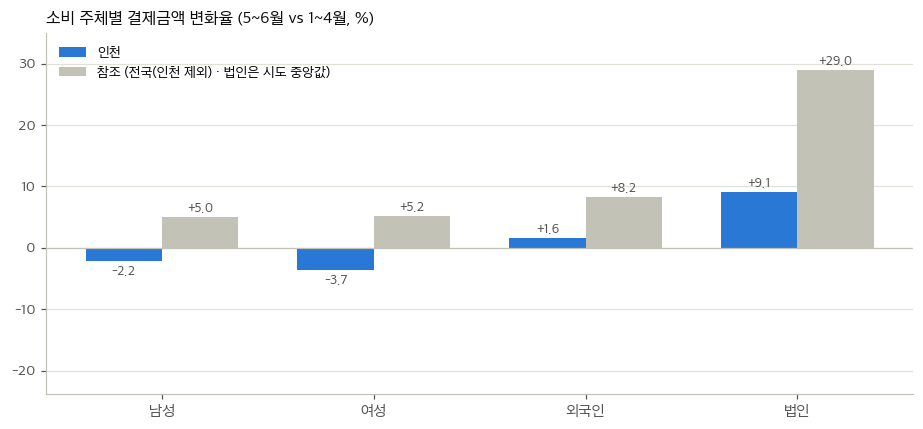

,남성,여성,외국인,법인
인천,-2.2,-3.7,1.6,9.1
참조,5.0,5.2,8.2,29.0
격차,-7.1,-8.9,-6.6,-19.9


법인 시도별 변화율(%) — 분산이 매우 커서 법인은 약한 대조군:
SIDO_NM
세종특별자치시     6.6
대구광역시       8.9
인천광역시       9.1
충청북도       11.6
경상북도       13.7
대전광역시      17.1
서울특별시      19.1
경기도        22.3
충청남도       26.4
강원특별자치도    31.6
전북특별자치도    34.3
광주광역시      68.7
제주특별자치도   109.9
전라남도      206.7
울산광역시     208.7
부산광역시     301.4
경상남도      592.6


In [38]:
corp, frn = df[df.seg == "법인"], df[df.seg == "외국인"]
corp_sido = prepost(corp, "SIDO_NM").sort_values()
ref_corp  = corp_sido.drop("인천광역시").median()        # 법인은 부산·경남 등 이상 급증 → 전국 합계 대신 시도 중앙값을 참조로

segs = pd.DataFrame({
    "인천": [pp_total(icn[icn.seg == "남성"]), pp_total(icn[icn.seg == "여성"]), pp_total(frn[frn.is_ic]), pp_total(corp[corp.is_ic])],
    "참조": [pp_total(nat[nat.seg == "남성"]), pp_total(nat[nat.seg == "여성"]), pp_total(frn[~frn.is_ic]), ref_corp],
}, index=["남성", "여성", "외국인", "법인"])
segs["격차"] = segs["인천"] - segs["참조"]

fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(4); w = 0.36
ax.bar(x - w / 2, segs["인천"], width=w, color=C["인천"], label="인천")
ax.bar(x + w / 2, segs["참조"], width=w, color=C["ref"], label="참조 (전국(인천 제외) · 법인은 시도 중앙값)")
for i in range(4):
    for dx, col in [(-w / 2, "인천"), (w / 2, "참조")]:
        v = segs.iloc[i][col]
        ax.text(i + dx, v + 0.5 if v >= 0 else v - 0.5, f"{v:+.1f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9, color=C["ink2"])
ax.set_xticks(x); ax.set_xticklabels(segs.index); ax.axhline(0, color=C["ref"], lw=0.8); ax.grid(axis="x", visible=False)
ax.set_ylim(segs.min().min() - 4, segs.max().max() + 6)
ax.set_title("소비 주체별 결제금액 변화율 (5~6월 vs 1~4월, %)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
display(segs.round(1).T)
print("법인 시도별 변화율(%) — 분산이 매우 커서 법인은 약한 대조군:"); print(corp_sido.round(1).to_string())

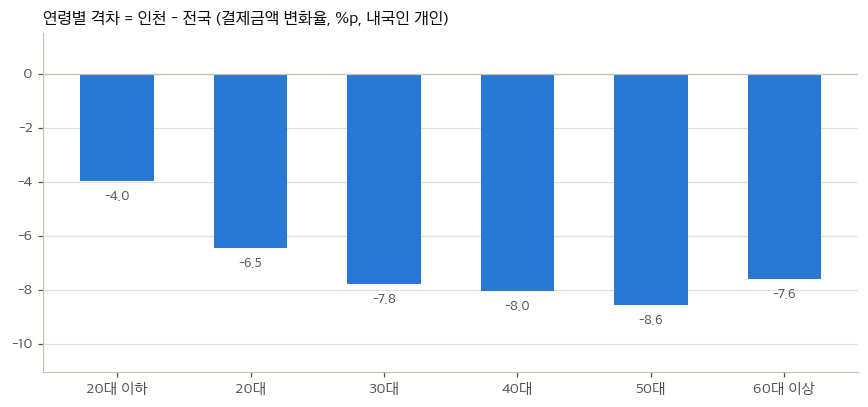

인천  전국(인천 제외)   격차
연령 20대 이하 -3.0        1.0 -4.0
   20대    -3.9        2.5 -6.5
   30대    -4.1        3.7 -7.8
   40대    -4.6        3.4 -8.0
   50대    -4.3        4.2 -8.6
   60대 이상  1.2        8.8 -7.6
성별 남성     -2.2        5.0 -7.1
   여성     -3.7        5.2 -8.9

In [39]:
age_pp = pd.DataFrame({"인천": prepost(icn, "age"), "전국(인천 제외)": prepost(nat, "age")}).reindex(AGE_ORDER)
age_pp["격차"] = age_pp["인천"] - age_pp["전국(인천 제외)"]
gen_pp = pd.DataFrame({"인천": prepost(icn, "seg"), "전국(인천 제외)": prepost(nat, "seg")})
gen_pp["격차"] = gen_pp["인천"] - gen_pp["전국(인천 제외)"]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(range(6), age_pp["격차"], color=C["인천"], width=0.55)
for i, v in enumerate(age_pp["격차"]):
    ax.text(i, v - 0.3, f"{v:+.1f}", ha="center", va="top", fontsize=9, color=C["ink2"])
ax.set_xticks(range(6)); ax.set_xticklabels(AGE_ORDER); ax.axhline(0, color=C["ref"], lw=0.8); ax.grid(axis="x", visible=False)
ax.set_ylim(age_pp["격차"].min() - 2.5, 1.5)
ax.set_title("연령별 격차 = 인천 - 전국 (결제금액 변화율, %p, 내국인 개인)")
plt.tight_layout(); plt.show()
display(pd.concat({"연령": age_pp, "성별": gen_pp}).round(1))

- 개인은 **성별·연령을 가리지 않고 -4 ~ -9pt** 빠졌고, 30~50대가 가장 크다. 외국인도 -6.6pt로 개인과 같은 방향.
- **법인은 마이너스가 아니다**(+9.1%). 시도 중앙값(+29%)보다는 낮지만 법인은 5~6월 전국적으로 이상 급증(부산·경남 수백 %)이 있어 분산이 커, 방향만 확인하는 정도로 쓴다.

## B10. 인접 지역 — 경계 밖으로 새는가
인천 거주자가 e음을 쓰려고 소비를 인천 안으로 되돌렸다면, 인접한 경기 지역(부천·김포·시흥)의 소비가 함께 약해질 수 있다.

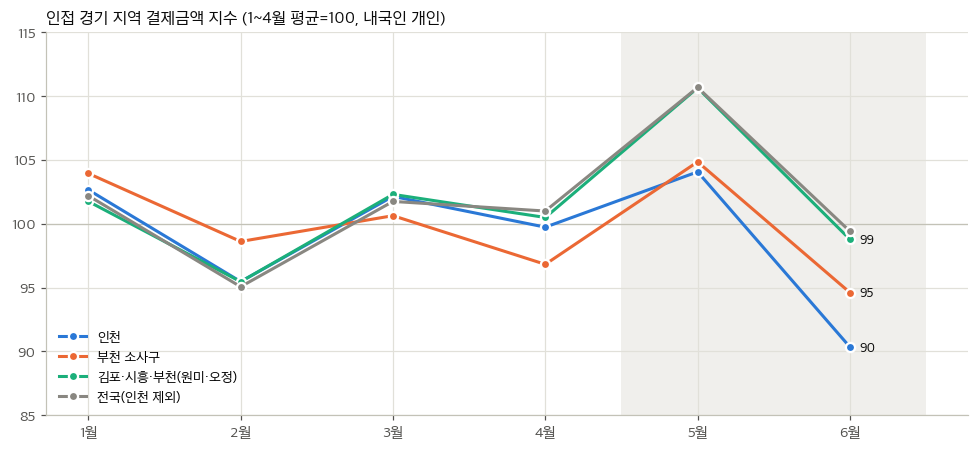

CCG_NM,김포시,부천시 소사구,부천시 오정구,부천시 원미구,시흥시
변화율 % (5~6월 vs 1~4월),4.1,-0.3,5.5,4.0,5.4
전국(인천 제외),5.0,5.0,5.0,5.0,5.0


In [40]:
NB = {"부천 소사구": ["부천시 소사구"], "김포·시흥·부천(원미·오정)": ["김포시", "시흥시", "부천시 원미구", "부천시 오정구"]}
fig, ax = plt.subplots(figsize=(9, 4.2))
line(ax, idx(msum(icn)), "인천")
for name, ccgs in NB.items():
    d = nat[nat.SIDO_NM.eq("경기도") & nat.CCG_NM.isin(ccgs)]
    line(ax, idx(msum(d)), name, color=C["서울·경기"] if "소사" in name else C["5대 광역시"])
line(ax, idx(msum(nat)), "전국(인천 제외)", label_end=False)
shade(ax); ax.set_ylim(85, 115); ax.legend(loc="lower left")
ax.set_title("인접 경기 지역 결제금액 지수 (1~4월 평균=100, 내국인 개인)")
plt.tight_layout(); plt.show()

nb_all = nat[nat.SIDO_NM.eq("경기도") & nat.CCG_NM.isin(sum(NB.values(), []))]
display(pd.DataFrame({"변화율 % (5~6월 vs 1~4월)": prepost(nb_all, "CCG_NM"),
                      "전국(인천 제외)": pp_total(nat)}).round(1).T)

- 인접 지역 대부분은 전국과 같이 움직인다. **부천 소사구만** 인천과 비슷하게 처진다(경계 상권 유출 가능성). 본분석에서 인접 시군구를 대조군에 넣을지, 별도 스필오버 군으로 뺄지 결정할 근거.

## B11. 요약과 본분석 설계

### 핵심 발견
| # | 발견 | 근거 |
|---|---|---|
| 1 | 인천 BC카드 개인 소비는 1~4월엔 전국과 동행하다가 **5월 -6.0%, 6월 -9.1%** 갭 (두 달 약 **-190억원**) | B5 |
| 2 | 17개 시도 중 **유일한 마이너스**, 도시 8개 구 중 7개가 전국 하위 9위 안 | B6 |
| 3 | **e음 불가 업종(대형할인점) 격차 ≈ 0, 소상공인 업종 -7~-14pt** — 정책 적격성과 격차가 일치 | B7 |
| 4 | 개인은 전 연령·성별·외국인까지 빠졌고, **법인은 빠지지 않음** | B9 |
| 5 | 강화·옹진의 상승은 군 단위 관광 계절성, 인접 지역 중 부천 소사구만 동반 약세 | B8·B10 |

### 본분석 설계 (EDA가 정한 것)
- **처치군** 인천 도시 8개 구 × 내국인 개인 (강화·옹진은 별도 처리) · **대조군** 5대 광역시 또는 전국 시군구 (부천 소사구 등 인접 지역 제외 여부 검토)
- **사전/사후** 1~4월 / 5~6월 (4월 이연 가능성 → 1~3월만으로도 재추정) · **결과 변수** 금액·건수 (객단가는 변화 없음)
- **이중차분(DID)** 인천 × 사후 · **삼중차분(DDD)** 에 업종 적격 여부(대형할인점 = 플라시보)를 더해 계절·지역 공통 충격 제거
- **이벤트 스터디** 월별 계수로 4월 선행, 5→6월 확대 확인 · **대체율** = BC카드 갭 ÷ e음 결제 증가액 (외부 데이터 필요)

### 한계
- BC카드 한 회사의 데이터 → 대체 규모는 BC 점유율만큼만 보인다. 6개월뿐이라 연간 계절성을 완전히 통제할 수 없고, **7월 캐시백 중단 국면이 없다.**
- e음 결제액·가입자, 인구, 카드사 점유율이 없어 1인당 정규화와 대체율 산출은 외부 데이터가 있어야 한다.
- 5~6월 법인 소비의 전국적 이상 급증(부산·경남)은 법인을 대조군으로 쓰기 어렵게 한다.

### 필요한 외부 데이터
인천e음 월별 결제액·충전액·가입자(인천시/코나아이) · 시군구 주민등록인구 · 카드사별 시장점유율 · 소상공인 가맹점 수